In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
from matplotlib.colors import LinearSegmentedColormap

# Load the main dataset and the question mappings
df_all = pd.read_csv('apr6_data.csv')
df_questions = pd.read_csv('survey_results.csv', nrows=1)
question_map = df_questions.iloc[0].to_dict()

# Remove the extra header row if it exists in the data
df_all = df_all[df_all['Q11'] != 'At which UC campus do you currently teach?']

# Campus Group (Berkeley vs. Non-Berkeley)
df_all['Campus_Group'] = np.where(df_all['Q11'] == 'UC Berkeley', 'Berkeley', 'Non-Berkeley')

# Faculty Status Group (Senate vs. Non-Senate)
df_all['Faculty_Status'] = np.where(df_all['Q12'].str.contains('Senate', na=False), 'Senate Faculty', 'Non-Senate Faculty')

# Discipline Group (STEM vs. Non-STEM)
stem_flag = df_all.apply(lambda row: row.astype(str).str.contains('Science, Technology, Engineering, and Math', na=False).any(), axis=1)
df_all['Discipline_Group'] = np.where(stem_flag, 'STEM', 'Non-STEM')

print(f"Total respondents in full dataset: {len(df_all)}")

Total respondents in full dataset: 268


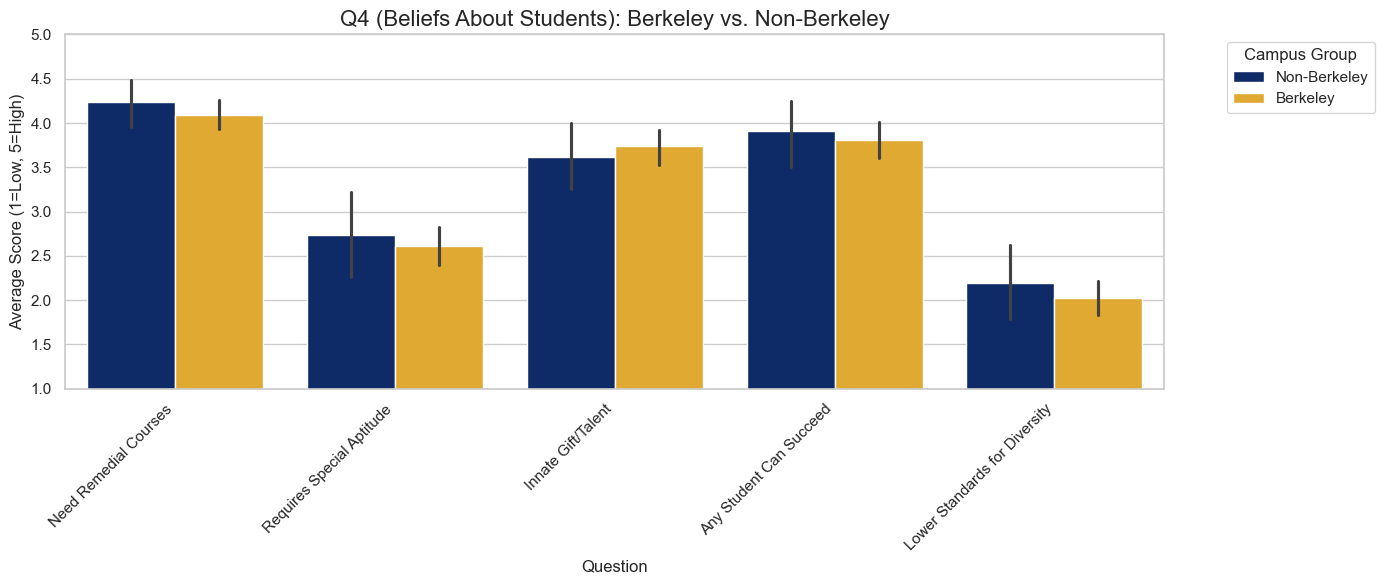

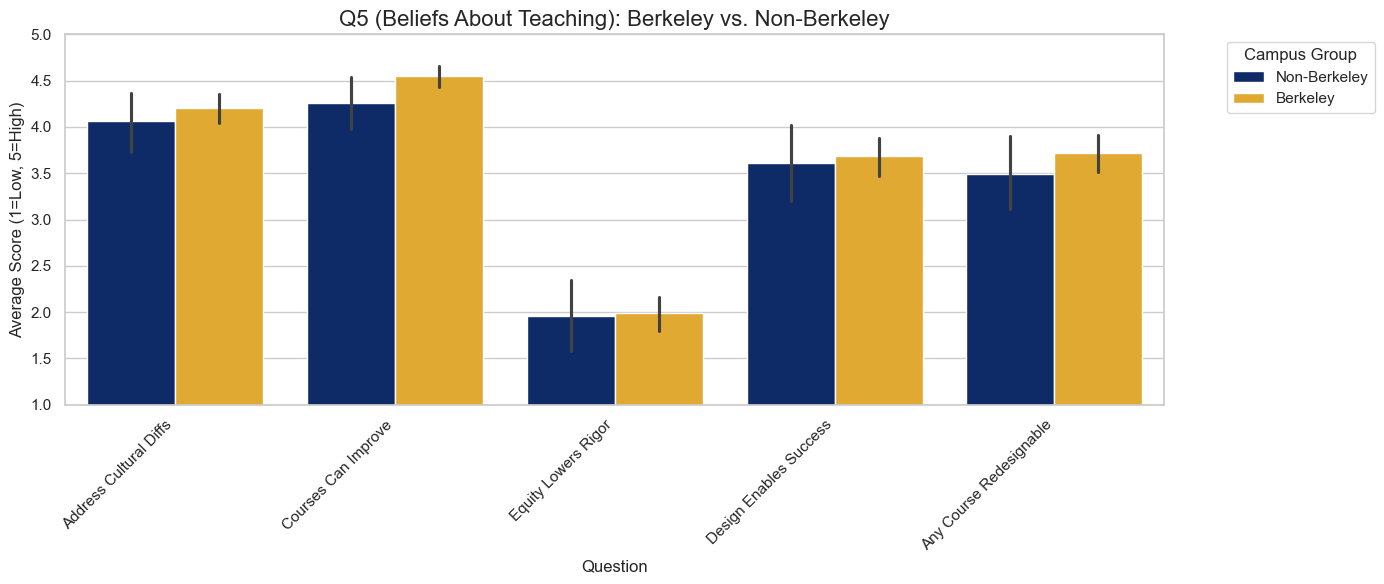

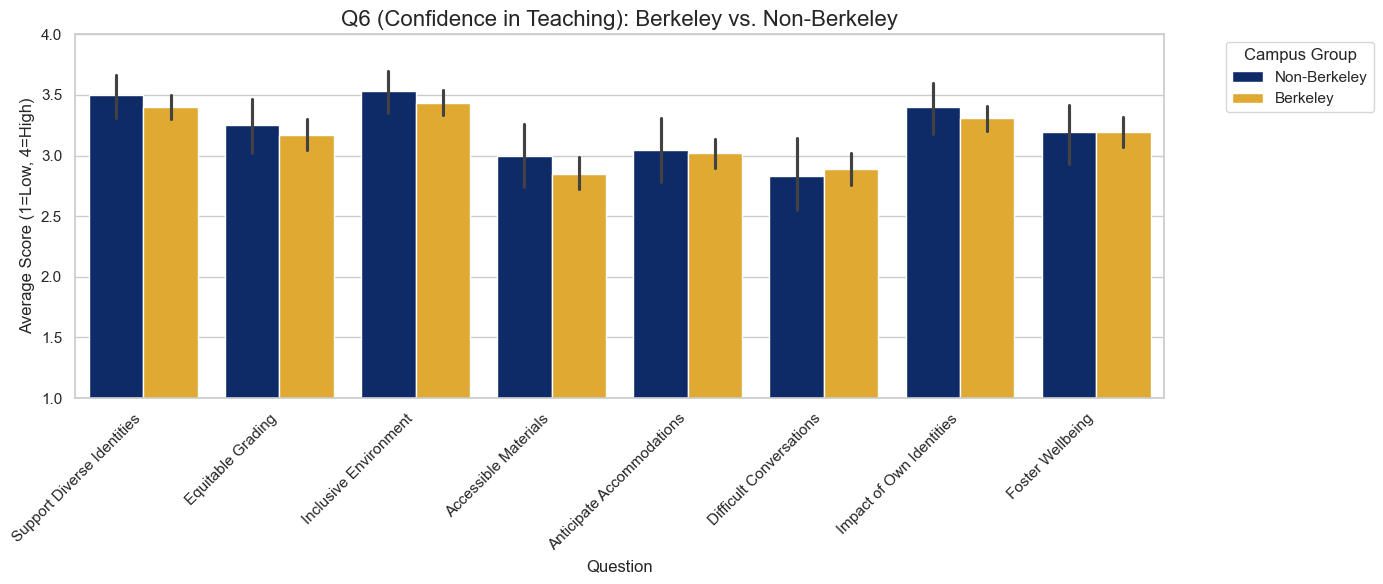

Dataset successfully filtered to 160 UC Berkeley respondents.


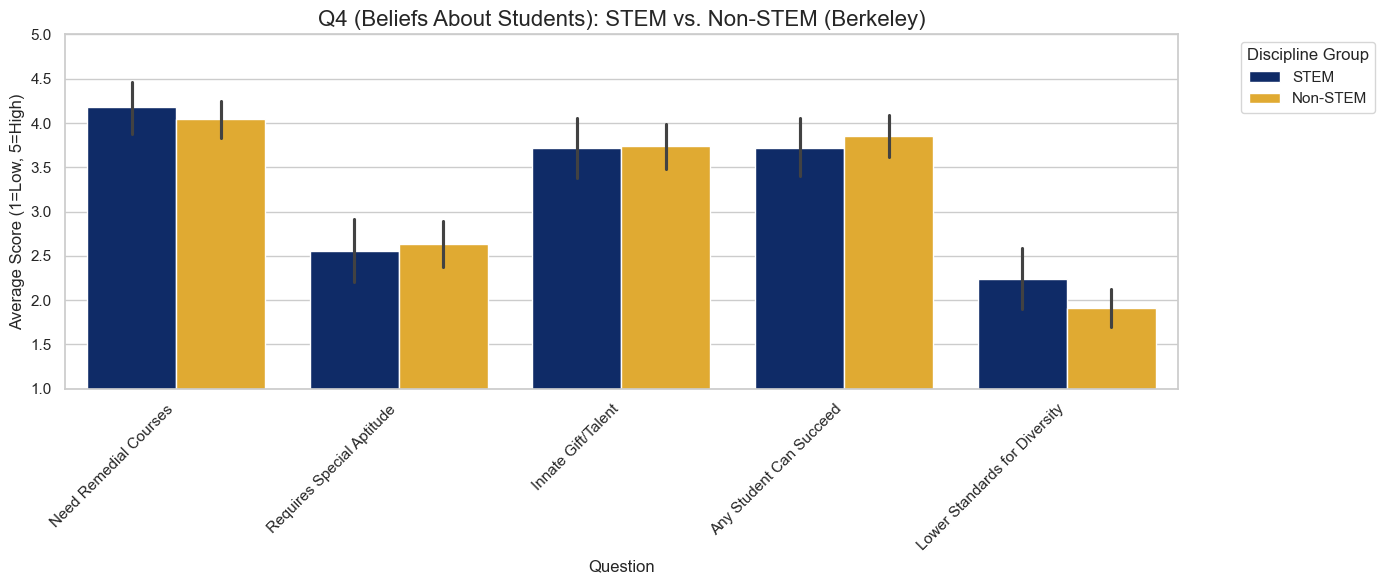

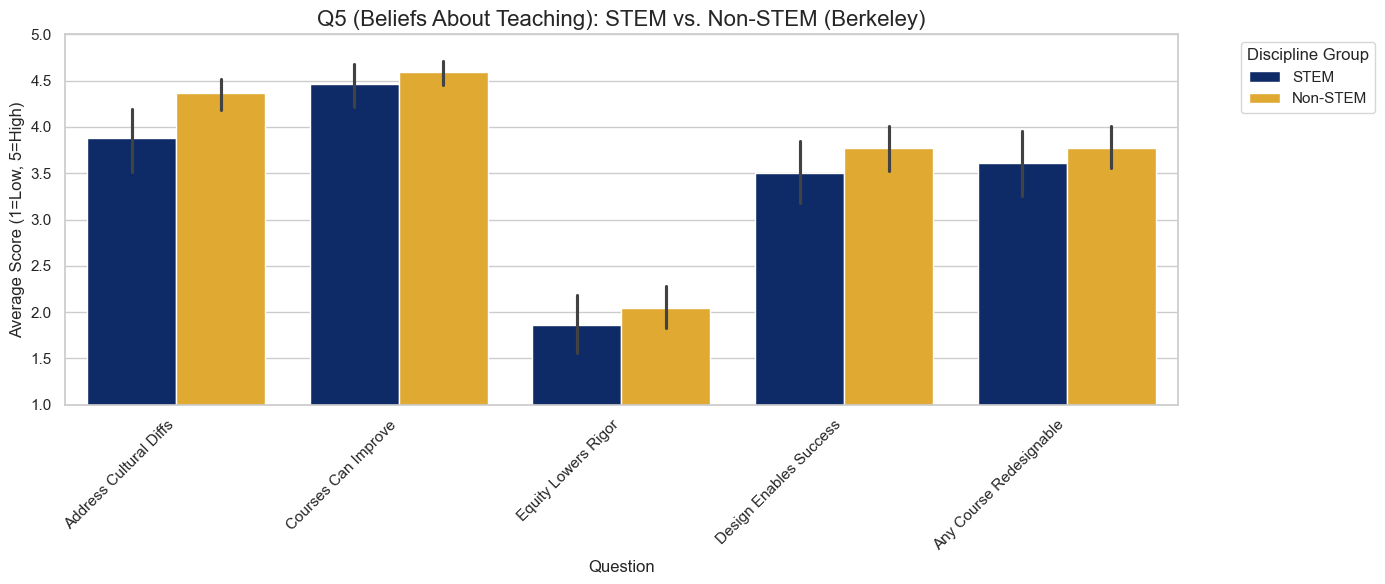

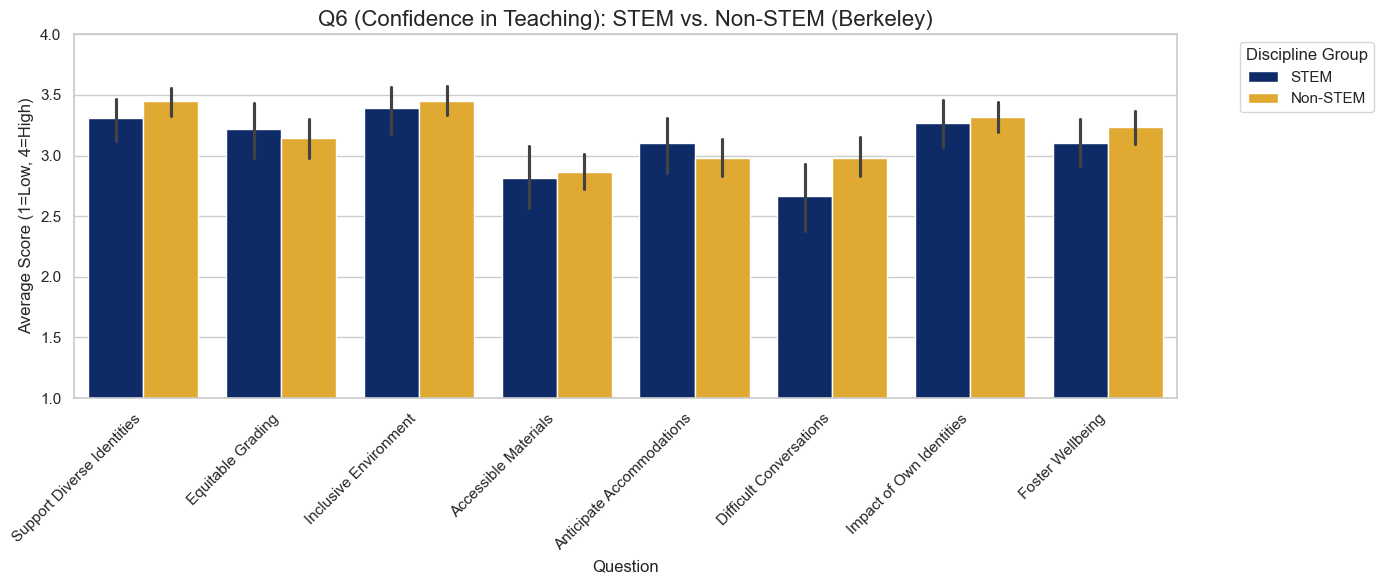

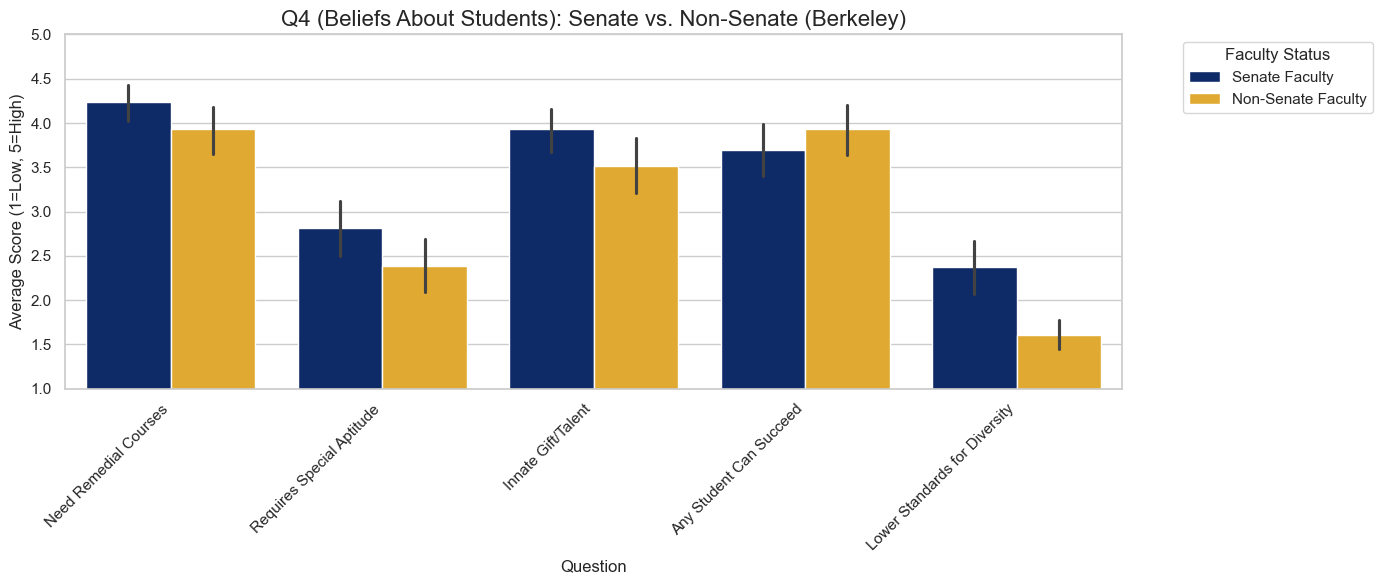

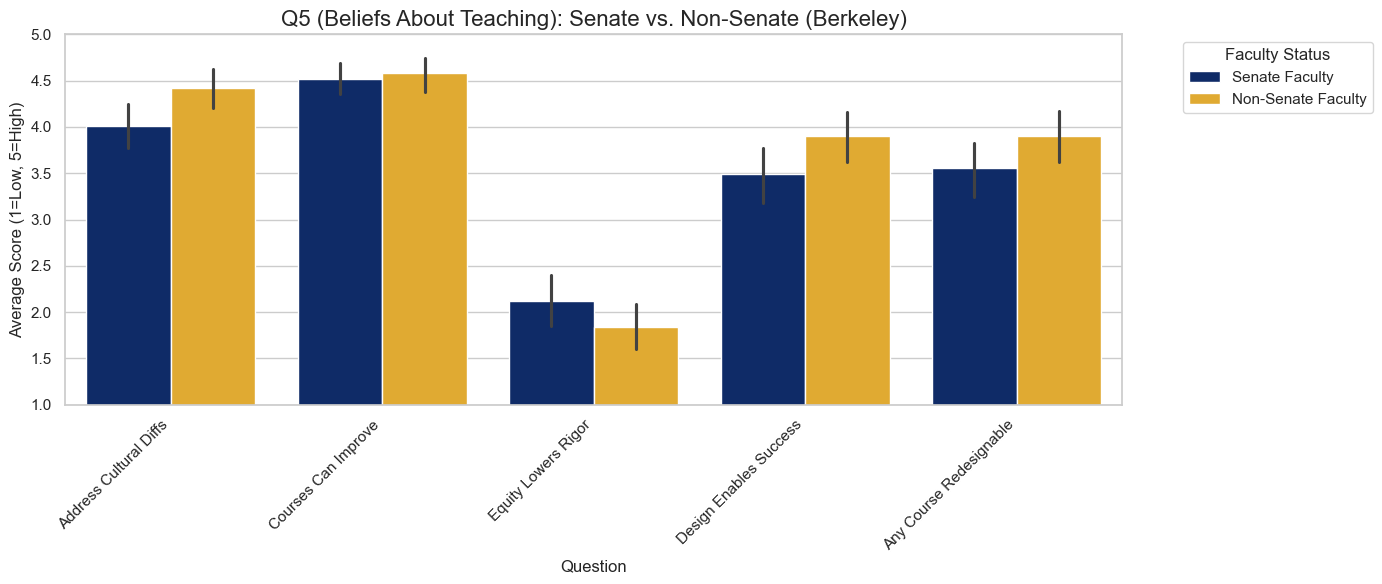

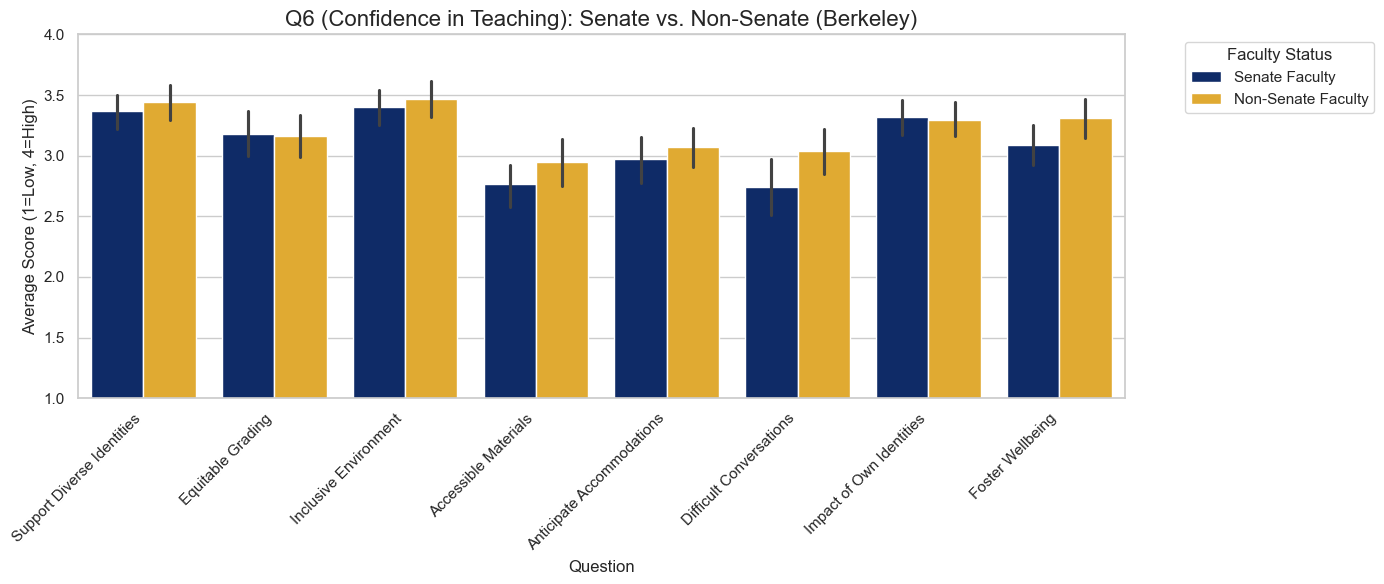

In [63]:
def plot_likert_comparison(data, question_prefix, group_col, title):
    # Map text responses to numeric scores
    agree_map = {'Strongly disagree': 1, 'Somewhat disagree': 2, 'Neutral': 3, 'Somewhat agree': 4, 'Strongly agree': 5}
    conf_map = {'Not confident at all': 1, 'Slightly confident': 2, 'Moderately confident': 3, 'Very confident': 4}
    
    # Dictionary of short summaries for the x-axis
    short_labels = {
        'Q4_1': 'Need Remedial Courses',
        'Q4_2': 'Requires Special Aptitude',
        'Q4_3': 'Innate Gift/Talent',
        'Q4_4': 'Any Student Can Succeed',
        'Q4_5': 'Lower Standards for Diversity',
        'Q5_1': 'Address Cultural Diffs',
        'Q5_2': 'Courses Can Improve',
        'Q5_3': 'Equity Lowers Rigor',
        'Q5_4': 'Design Enables Success',
        'Q5_5': 'Any Course Redesignable',
        'Q6_1': 'Support Diverse Identities',
        'Q6_2': 'Equitable Grading',
        'Q6_3': 'Inclusive Environment',
        'Q6_4': 'Accessible Materials',
        'Q6_5': 'Anticipate Accommodations',
        'Q6_6': 'Difficult Conversations',
        'Q6_7': 'Impact of Own Identities',
        'Q6_8': 'Foster Wellbeing'
    }
    
    mapping = conf_map if question_prefix == 'Q6_' else agree_map
    cols = [c for c in data.columns if c.startswith(question_prefix)]
    
    # Create a temporary dataframe with numeric values
    df_temp = data[[group_col] + cols].copy()
    for c in cols:
        df_temp[c] = df_temp[c].map(mapping)
        
    # Melt dataframe for Seaborn plotting
    df_melted = df_temp.melt(id_vars=[group_col], value_vars=cols, 
                             var_name='Question', value_name='Average Score')
    
    # Map the raw column names to the short summary labels
    df_melted['Question'] = df_melted['Question'].map(short_labels)
    
    plt.figure(figsize=(14, 6))
    
    # Brand Colors (Berkeley Blue & Gold)
    brand_palette = ['#002676', '#FDB515']
    
    sns.barplot(data=df_melted, x='Question', y='Average Score', hue=group_col, palette=brand_palette, errorbar=('ci', 95))
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right')
    
    # Move legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=group_col.replace('_', ' '))
    
    # Set y-axis limits dynamically based on the scale
    if question_prefix == 'Q6_':
        plt.ylim(1, 4)
        plt.ylabel('Average Score (1=Low, 4=High)')
    else:
        plt.ylim(1, 5)
        plt.ylabel('Average Score (1=Low, 5=High)')
        
    plt.tight_layout()
    plt.show()


question_blocks = {
    'Q4_': 'Q4 (Beliefs About Students)',
    'Q5_': 'Q5 (Beliefs About Teaching)',
    'Q6_': 'Q6 (Confidence in Teaching)'
}

# CAMPUS COMPARISON
for q_prefix, q_name in question_blocks.items():
    title = f"{q_name}: Berkeley vs. Non-Berkeley"
    plot_likert_comparison(df_all, q_prefix, 'Campus_Group', title)


# FILTER DATASET TO BERKELEY ONLY
df = df_all[df_all['Campus_Group'] == 'Berkeley'].copy()
print(f"Dataset successfully filtered to {len(df)} UC Berkeley respondents.")

groupings_berkeley = {
    'Discipline_Group': 'STEM vs. Non-STEM (Berkeley)',
    'Faculty_Status': 'Senate vs. Non-Senate (Berkeley)'
}

for group_col, group_name in groupings_berkeley.items():
    for q_prefix, q_name in question_blocks.items():
        title = f"{q_name}: {group_name}"
        plot_likert_comparison(df, q_prefix, group_col, title)

In [64]:
# Filter down to just Berkeley respondents for the remainder of the analysis
df = df_all[df_all['Campus_Group'] == 'Berkeley'].copy()
print(f"Total Berkeley respondents: {len(df)}")

Total Berkeley respondents: 160


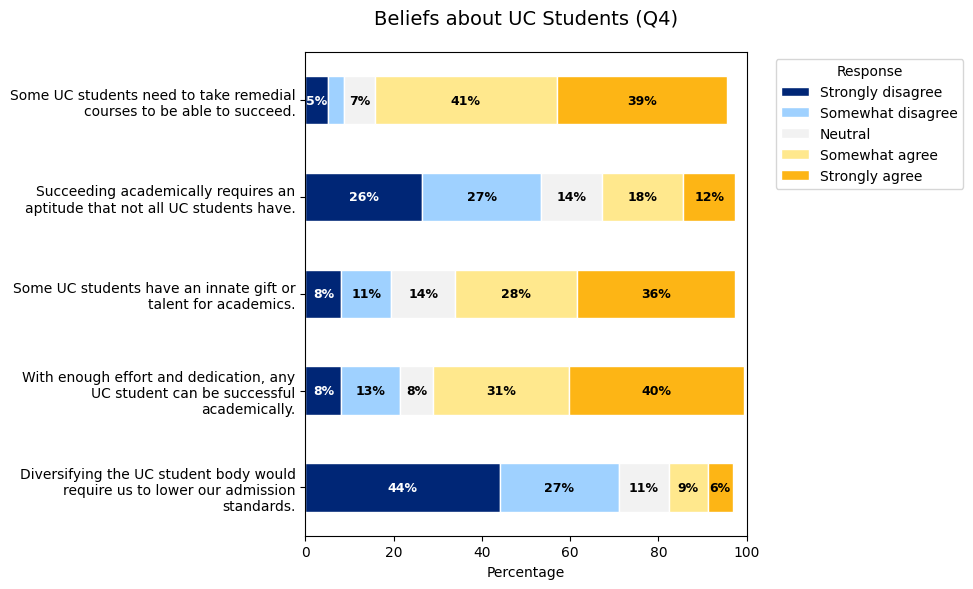

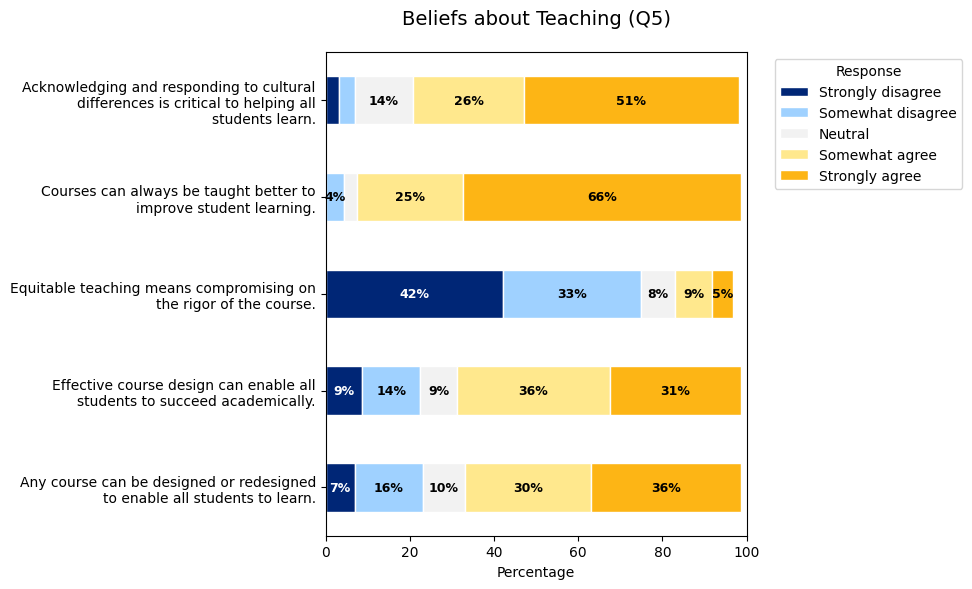

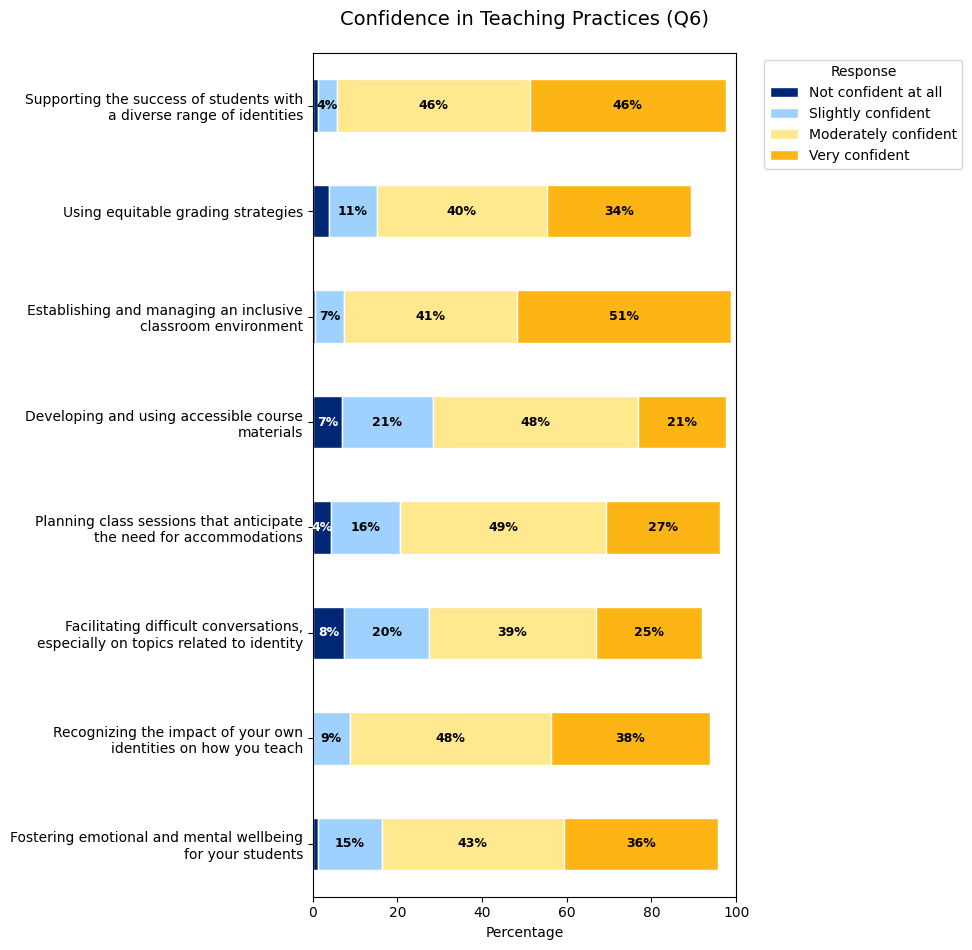

In [6]:
agree_order = ['Strongly disagree', 'Somewhat disagree', 'Neutral', 'Somewhat agree', 'Strongly agree']
conf_order = ['Not confident at all', 'Slightly confident', 'Moderately confident', 'Very confident']

custom_colors_5 = ['#002676', '#9FD1FF', '#F2F2F2', '#FFE88D', '#FDB515']
text_colors_5 = ['white', 'black', 'black', 'black', 'black']

custom_colors_4 = ['#002676', '#9FD1FF', '#FFE88D', '#FDB515']
text_colors_4 = ['white', 'black', 'black', 'black']

q4_cols = [c for c in df.columns if c.startswith('Q4_')]
q5_cols = [c for c in df.columns if c.startswith('Q5_')]
q6_cols = [c for c in df.columns if c.startswith('Q6_')]

def plot_likert_block(data, cols, order, title, q_map, color_palette, text_colors):
    results = {}
    for col in cols:
        full_text = q_map.get(col, col)
        label = full_text.split('-')[-1].strip() if '-' in full_text else full_text
        label = textwrap.fill(label, width=40)
        vc = data[col].value_counts(normalize=True).reindex(order, fill_value=0) * 100
        results[label] = vc
        
    plot_df = pd.DataFrame(results).T
    fig, ax = plt.subplots(figsize=(10, len(cols) * 1.2))
    plot_df.plot(kind='barh', stacked=True, ax=ax, color=color_palette, edgecolor='white')
    
    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xlabel('Percentage')
    ax.set_xlim(0, 100)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Response")
    ax.invert_yaxis()
    
    for i, c in enumerate(ax.containers):
        t_color = text_colors[i] if i < len(text_colors) else 'black'
        labels = [f'{v.get_width():.0f}%' if v.get_width() > 4 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', color=t_color, fontsize=9, weight='bold')
        
    plt.tight_layout()
    plt.show()

plot_likert_block(df, q4_cols, agree_order, "Beliefs about UC Students (Q4)", question_map, custom_colors_5, text_colors_5)
plot_likert_block(df, q5_cols, agree_order, "Beliefs about Teaching (Q5)", question_map, custom_colors_5, text_colors_5)
plot_likert_block(df, q6_cols, conf_order, "Confidence in Teaching Practices (Q6)", question_map, custom_colors_4, text_colors_4)

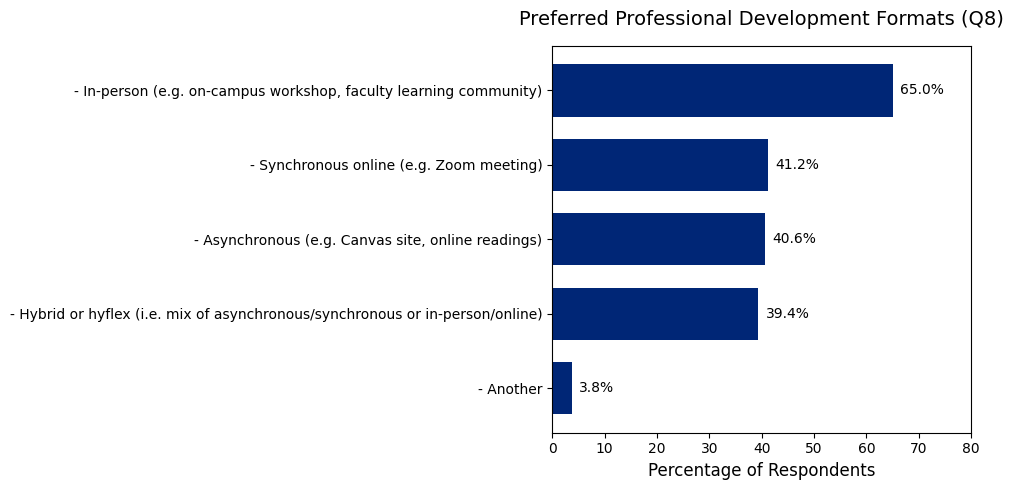

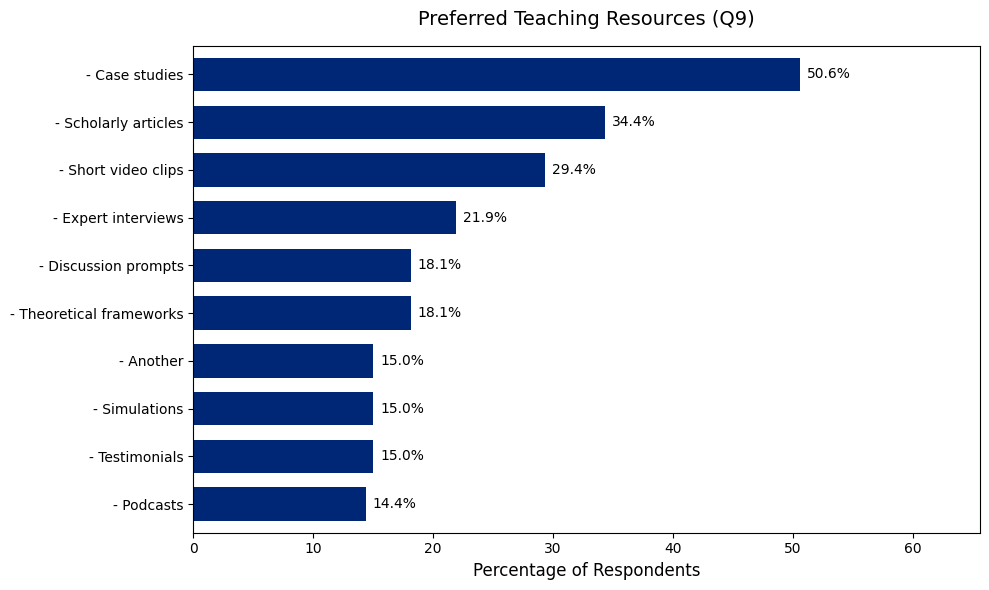

In [7]:
def plot_multi_select(data, q_prefix, title):
    cols = [c for c in data.columns if c.startswith(q_prefix) and not c.endswith('_TEXT')]
    counts = {}
    for col in cols:
        full_label = question_map.get(col, col)
        if "Selected Choice" in full_label:
            label = full_label.split("Selected Choice")[-1].strip()
        else:
            label = full_label.split("-")[-1].strip()
            
        if "Another" in label:
            label = label.split(" ")[0] + " " + label.split(" ")[1] # Simplify "Another format/resource"
            
        count = data[col].notna().sum()
        counts[label] = count
        
    count_df = pd.DataFrame.from_dict(counts, orient='index', columns=['Count'])
    count_df['Percentage'] = (count_df['Count'] / len(data)) * 100
    count_df = count_df.sort_values('Percentage', ascending=True)
    
    plt.figure(figsize=(10, max(5, len(cols)*0.6)))
    ax = count_df['Percentage'].plot(kind='barh', color='#002676', width=0.7)
    
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Percentage of Respondents', fontsize=12)
    plt.ylabel('')
    
    # Automatically sets the limit to the highest bar's value + 15% padding
    plt.xlim(0, count_df['Percentage'].max() + 15)
    
    for c in ax.containers:
        ax.bar_label(c, fmt='%.1f%%', padding=5, fontsize=10)
        
    plt.tight_layout()
    plt.show()

# Now we don't need to pass manual limits like 65 or 45 anymore!
plot_multi_select(df, 'Q8_', 'Preferred Professional Development Formats (Q8)')
plot_multi_select(df, 'Q9_', 'Preferred Teaching Resources (Q9)')

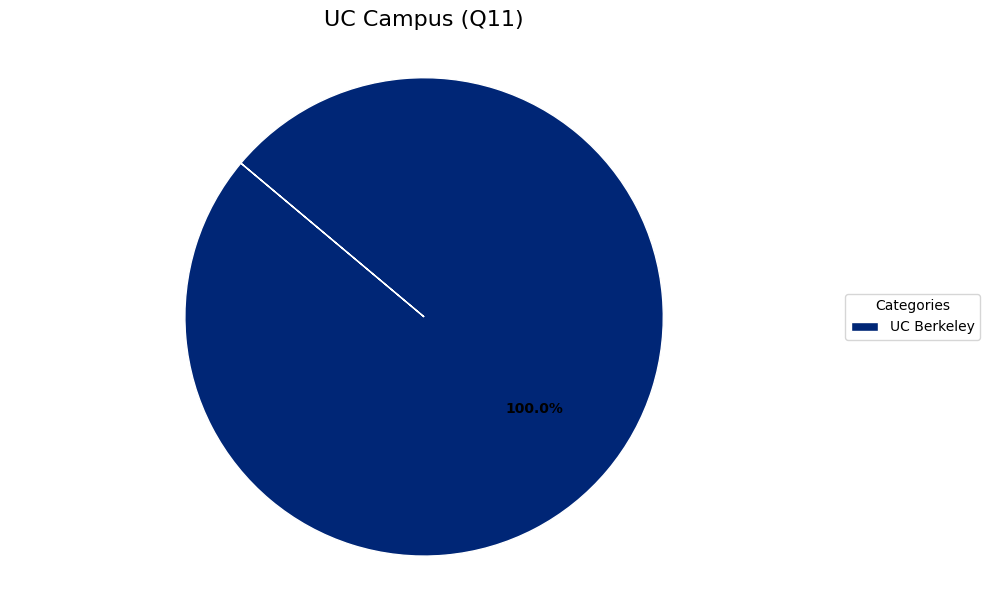

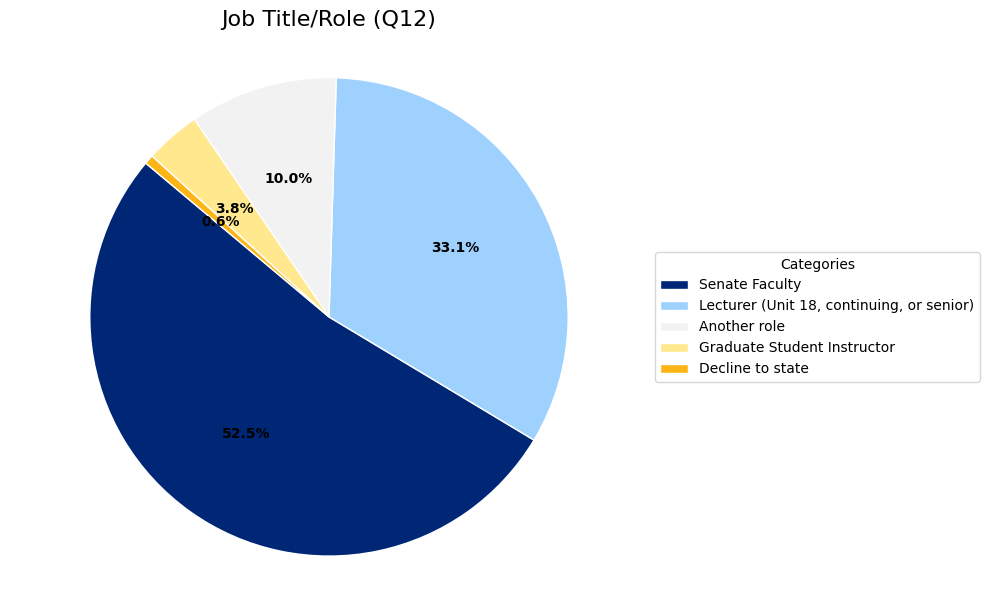

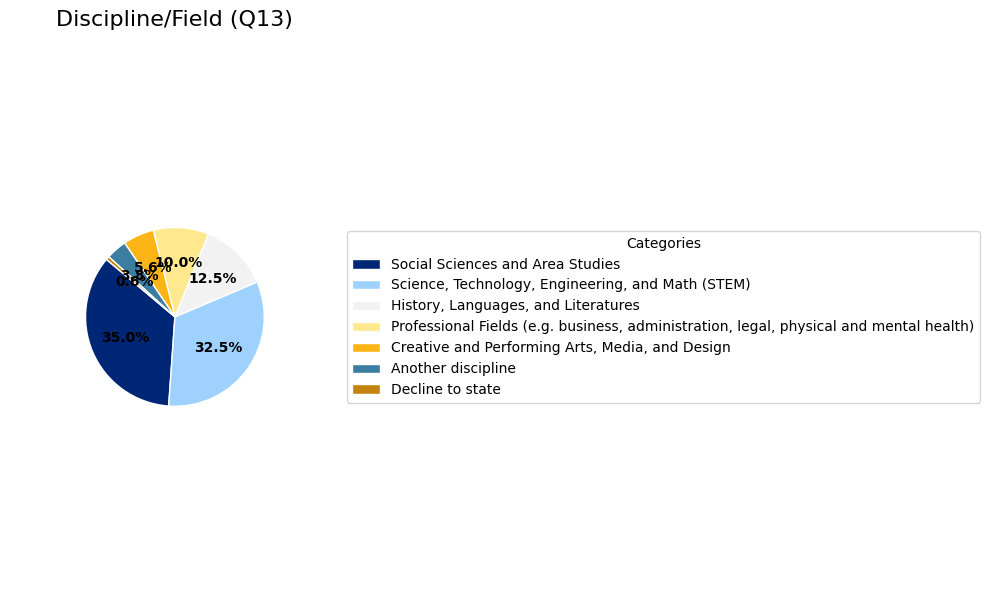

In [8]:
columns_map = {
    'Q11': 'UC Campus (Q11)',
    'Q12': 'Job Title/Role (Q12)',
    'Q13': 'Discipline/Field (Q13)'
}
custom_colors = ['#002676', '#9FD1FF', '#F2F2F2', '#FFE88D', '#FDB515', '#3B7EA1', '#C4820E']

def plot_pie_chart_with_legend(data, col, title, colors):
    counts = data[col].value_counts()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    wedges, texts, autotexts = ax.pie(
        counts,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors[:len(counts)],
        wedgeprops={'edgecolor': 'white'}
    )
    
    plt.setp(autotexts, size=10, weight="bold")
    
    # Add a color-coded legend
    ax.legend(wedges, counts.index,
              title="Categories",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))
              
    plt.title(title, fontsize=16, pad=20)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

for col, title in columns_map.items():
    plot_pie_chart_with_legend(df, col, title, custom_colors)

Cronbach's Alpha (Growth/Equity Items): 0.807
Cronbach's Alpha (Confidence Items Q6): 0.832


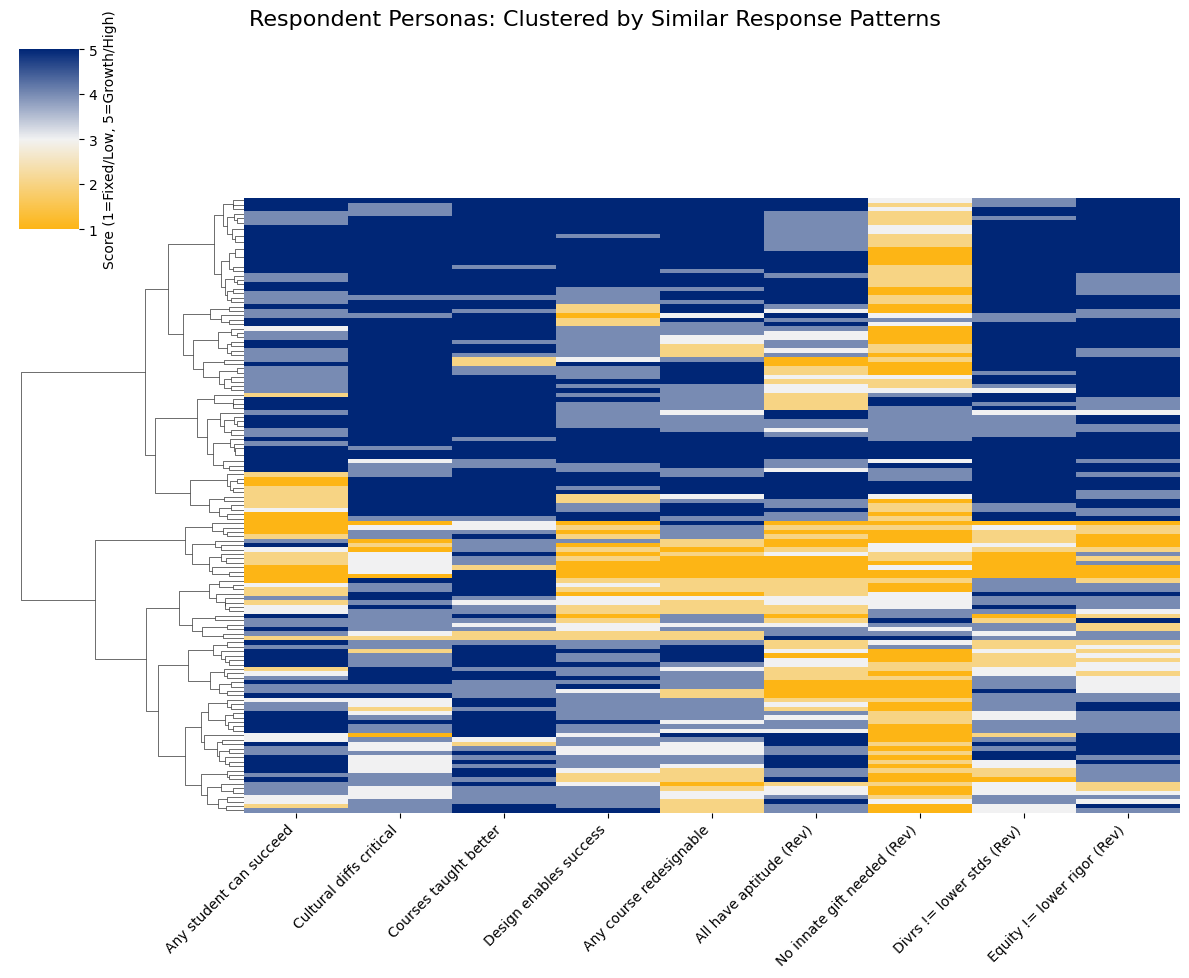

In [9]:
# Mappings for Cronbach/Personas
agree_map = {'Strongly disagree': 1, 'Somewhat disagree': 2, 'Neutral': 3, 'Somewhat agree': 4, 'Strongly agree': 5, 'Unsure / Unapplicable': np.nan}
conf_map = {'Not confident at all': 1, 'Slightly confident': 2, 'Moderately confident': 3, 'Very confident': 4, 'Unsure / Unapplicable': np.nan}

df_num = df.copy()

for c in q4_cols + q5_cols:
    df_num[c] = df[c].map(agree_map)
for c in q6_cols:
    df_num[c] = df[c].map(conf_map)

# Reverse Coding for Fixed Mindset Items
reverse_cols = ['Q4_2', 'Q4_3', 'Q4_5', 'Q5_3']
for c in reverse_cols:
    if c in df_num.columns:
        df_num[c+'_rev'] = 6 - df_num[c]

# Define composite items
growth_cols = ['Q4_4', 'Q5_1', 'Q5_2', 'Q5_4', 'Q5_5', 'Q4_2_rev', 'Q4_3_rev', 'Q4_5_rev', 'Q5_3_rev']
growth_cols = [c for c in growth_cols if c in df_num.columns] 

def cronbach_alpha(df_items):
    df_clean = df_items.dropna()
    item_scores = df_clean.values
    if item_scores.shape[1] <= 1: return np.nan
    item_vars = item_scores.var(axis=0, ddof=1)
    t_scores = item_scores.sum(axis=1)
    n_items = item_scores.shape[1]
    return (n_items / (n_items - 1)) * (1 - (item_vars.sum() / t_scores.var(ddof=1)))

print(f"Cronbach's Alpha (Growth/Equity Items): {cronbach_alpha(df_num[growth_cols]):.3f}")
print(f"Cronbach's Alpha (Confidence Items Q6): {cronbach_alpha(df_num[q6_cols]):.3f}")

# Create a custom colormap going from Gold to Grey to Dark Blue
berkeley_cmap = LinearSegmentedColormap.from_list('berkeley_brand', ['#FDB515', '#F2F2F2', '#002676'])

labels = {
    'Q4_4': 'Any student can succeed',
    'Q5_1': 'Cultural diffs critical',
    'Q5_2': 'Courses taught better',
    'Q5_4': 'Design enables success',
    'Q5_5': 'Any course redesignable',
    'Q4_2_rev': 'All have aptitude (Rev)',
    'Q4_3_rev': 'No innate gift needed (Rev)',
    'Q4_5_rev': 'Divrs != lower stds (Rev)',
    'Q5_3_rev': 'Equity != lower rigor (Rev)'
}

heatmap_data = df_num[growth_cols].dropna().rename(columns=labels)

# Generate a Clustermap (Rows=Respondents, Cols=Survey Items)
g = sns.clustermap(heatmap_data, 
                   cmap=berkeley_cmap, 
                   vmin=1, vmax=5, 
                   metric='euclidean', 
                   method='ward', 
                   figsize=(12, 10), 
                   row_cluster=True,   # Clusters respondents (creates Personas)
                   col_cluster=False,  # Keeps items in order
                   yticklabels=False,  # Hides individual respondent IDs
                   cbar_kws={'label': 'Score (1=Fixed/Low, 5=Growth/High)'})

g.fig.suptitle('Respondent Personas: Clustered by Similar Response Patterns', y=1.02, fontsize=16)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.show()

In [10]:
# Create a helper function to neatly print the counts and percentages
def print_group_summary(df, col_name, title):
    # Calculate counts and percentages
    counts = df[col_name].value_counts()
    percentages = df[col_name].value_counts(normalize=True) * 100
    
    # Combine into a clean DataFrame
    summary_df = pd.DataFrame({
        'Count': counts, 
        'Percentage (%)': percentages.map('{:.1f}%'.format)
    })
    
    print(f"=== {title} ===")
    print(summary_df.to_string())
    print("\n" + "-"*40 + "\n")

# Run the Campus summary on the FULL dataset
print(f"Total Valid Respondents (All Campuses): {len(df_all)}\n")
print_group_summary(df_all, 'Campus_Group', 'Berkeley vs. Non-Berkeley')

# Filter the dataset to Berkeley only
df_berkeley = df_all[df_all['Campus_Group'] == 'Berkeley'].copy()
print(f"Total Berkeley Respondents: {len(df_berkeley)}\n")

# Run the internal summaries on the BERKELEY dataset
print_group_summary(df_berkeley, 'Faculty_Status', 'Senate vs. Non-Senate (Berkeley Only)')
print_group_summary(df_berkeley, 'Discipline_Group', 'STEM vs. Non-STEM (Berkeley Only)')

Total Valid Respondents (All Campuses): 268

=== Berkeley vs. Non-Berkeley ===
              Count Percentage (%)
Campus_Group                      
Berkeley        160          59.7%
Non-Berkeley    108          40.3%

----------------------------------------

Total Berkeley Respondents: 160

=== Senate vs. Non-Senate (Berkeley Only) ===
                    Count Percentage (%)
Faculty_Status                          
Senate Faculty         84          52.5%
Non-Senate Faculty     76          47.5%

----------------------------------------

=== STEM vs. Non-STEM (Berkeley Only) ===
                  Count Percentage (%)
Discipline_Group                      
Non-STEM            108          67.5%
STEM                 52          32.5%

----------------------------------------



In [11]:
import pandas as pd
import numpy as np
from factor_analyzer import ConfirmatoryFactorAnalyzer, ModelSpecificationParser

# 1. PREPARE THE DATA (Numeric Mapping & Reverse Coding)
df_cfa = df_berkeley.copy() # Assumes 'df' is already loaded with your Berkeley subset

agree_map = {'Strongly disagree': 1, 'Somewhat disagree': 2, 'Neutral': 3, 
             'Somewhat agree': 4, 'Strongly agree': 5, 'Unsure / Unapplicable': np.nan}

q4_cols = ['Q4_1', 'Q4_2', 'Q4_3', 'Q4_4', 'Q4_5']
q5_cols = ['Q5_1', 'Q5_2', 'Q5_3', 'Q5_4', 'Q5_5']

for c in q4_cols + q5_cols:
    df_cfa[c] = df_cfa[c].map(agree_map)

# Reverse-code the "Fixed Mindset" items so higher score always = "Growth Mindset"
# (6 - score) flips a 1 to a 5, and a 5 to a 1.
rev_cols = ['Q4_1', 'Q4_2', 'Q4_3', 'Q4_5', 'Q5_3']
for c in rev_cols:
    if c in df_cfa.columns:
        df_cfa[c + '_rev'] = 6 - df_cfa[c]

# The final items going into our models
student_items = ['Q4_1_rev', 'Q4_2_rev', 'Q4_3_rev', 'Q4_4', 'Q4_5_rev']
teach_items = ['Q5_1', 'Q5_2', 'Q5_3_rev', 'Q5_4', 'Q5_5']

# Drop missing values specifically for the model fitting step
df_model = df_cfa[student_items + teach_items].dropna()

# ---------------------------------------------------------
# 2. CONFIRMATORY FACTOR ANALYSIS (CFA)
# ---------------------------------------------------------
from factor_analyzer import ModelSpecification, ConfirmatoryFactorAnalyzer
import sklearn.utils.validation
from factor_analyzer import confirmatory_factor_analyzer

# We have 10 total variables (5 for StudentBeliefs, 5 for TeachBeliefs)
n_variables = 10
n_factors = 2
factor_names = ["StudentBeliefs", "TeachBeliefs"]
variable_names = student_items + teach_items

# Create a matrix of zeros (0 means "do not link this variable to this factor")
loadings = np.zeros((n_variables, n_factors))

# Link the first 5 variables (0 through 4) to Factor 0 (StudentBeliefs)
loadings[0:5, 0] = np.nan

# Link the next 5 variables (5 through 9) to Factor 1 (TeachBeliefs)
loadings[5:10, 1] = np.nan

# Build the model specification manually
model_spec = ModelSpecification(
    loadings=loadings,
    n_factors=n_factors,
    n_variables=n_variables,
    factor_names=factor_names,
    variable_names=variable_names
)

# --- THE FIX: "Monkey Patch" the scikit-learn error ---
original_check_array = sklearn.utils.validation.check_array

def patched_check_array(*args, **kwargs):
    # If factor_analyzer uses the old name, translate it to the new name
    if 'force_all_finite' in kwargs:
        kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
    return original_check_array(*args, **kwargs)

# Apply the patch to factor_analyzer's internal code
confirmatory_factor_analyzer.check_array = patched_check_array
# ------------------------------------------------------

# Fit the CFA model
cfa = ConfirmatoryFactorAnalyzer(model_spec, disp=False)
cfa.fit(df_model.values)

print("=== CFA FACTOR LOADINGS ===")
loadings_df = pd.DataFrame(cfa.loadings_, index=variable_names, columns=factor_names)
print(loadings_df)

# ---------------------------------------------------------
# 3. CRONBACH'S ALPHA (Alpha-if-Item-Dropped)
# ---------------------------------------------------------
def item_dropped_alpha(df_items):
    items = df_items.columns
    k = len(items)
    cov_matrix = df_items.cov()
    total_var = cov_matrix.sum().sum()
    item_vars = np.diag(cov_matrix).sum()
    alpha = (k / (k - 1)) * (1 - item_vars / total_var)
    
    results = []
    for item in items:
        rem_items = [x for x in items if x != item]
        cov_rem = df_items[rem_items].cov()
        alpha_rem = (len(rem_items) / (len(rem_items) - 1)) * (1 - np.diag(cov_rem).sum() / cov_rem.sum().sum())
        item_tot_corr = np.corrcoef(df_items[item], df_items[rem_items].sum(axis=1))[0,1]
        results.append((item, alpha_rem, item_tot_corr))
        
    return alpha, pd.DataFrame(results, columns=['Dropped_Item', 'Alpha_if_Dropped', 'Item_Total_Corr'])

a4, res4 = item_dropped_alpha(df_model[student_items])
print(f"\n=== Q4 (Student Beliefs) Total Alpha: {a4:.3f} ===")
print(res4.to_string(index=False))

a5, res5 = item_dropped_alpha(df_model[teach_items])
print(f"\n=== Q5 (Teaching Beliefs) Total Alpha: {a5:.3f} ===")
print(res5.to_string(index=False))

# ---------------------------------------------------------
# 4. CALCULATE SCORES FOR EVERY PERSON
# ---------------------------------------------------------
# Calculates the average of the 5 statements for each respondent
df['StudentBeliefs_Score'] = df_cfa[student_items].mean(axis=1)
df['TeachBeliefs_Score'] = df_cfa[teach_items].mean(axis=1)

print("\n=== SCORES ASSIGNED TO ORIGINAL DATAFRAME ===")
print(df[['StudentBeliefs_Score', 'TeachBeliefs_Score']].head())

=== CFA FACTOR LOADINGS ===
          StudentBeliefs  TeachBeliefs
Q4_1_rev        0.775131      0.000000
Q4_2_rev        1.129407      0.000000
Q4_3_rev        0.817281      0.000000
Q4_4            0.868659      0.000000
Q4_5_rev        1.038402      0.000000
Q5_1            0.000000      0.890916
Q5_2            0.000000      0.589753
Q5_3_rev        0.000000      1.007351
Q5_4            0.000000      1.086077
Q5_5            0.000000      1.077608

=== Q4 (Student Beliefs) Total Alpha: 0.564 ===
Dropped_Item  Alpha_if_Dropped  Item_Total_Corr
    Q4_1_rev          0.538824         0.265895
    Q4_2_rev          0.383767         0.508190
    Q4_3_rev          0.596926         0.165938
        Q4_4          0.572946         0.212454
    Q4_5_rev          0.400224         0.506192

=== Q5 (Teaching Beliefs) Total Alpha: 0.765 ===
Dropped_Item  Alpha_if_Dropped  Item_Total_Corr
        Q5_1          0.715225         0.556625
        Q5_2          0.775257         0.350881
    Q5_3_rev

c:\Users\lynnc\OneDrive\Desktop\UC Instructor Viewpoints\.venv-1\Lib\site-packages\factor_analyzer\confirmatory_factor_analyzer.py:753: UserWarning: The optimization routine failed to converge: ABNORMAL: 
  warnings.warn(


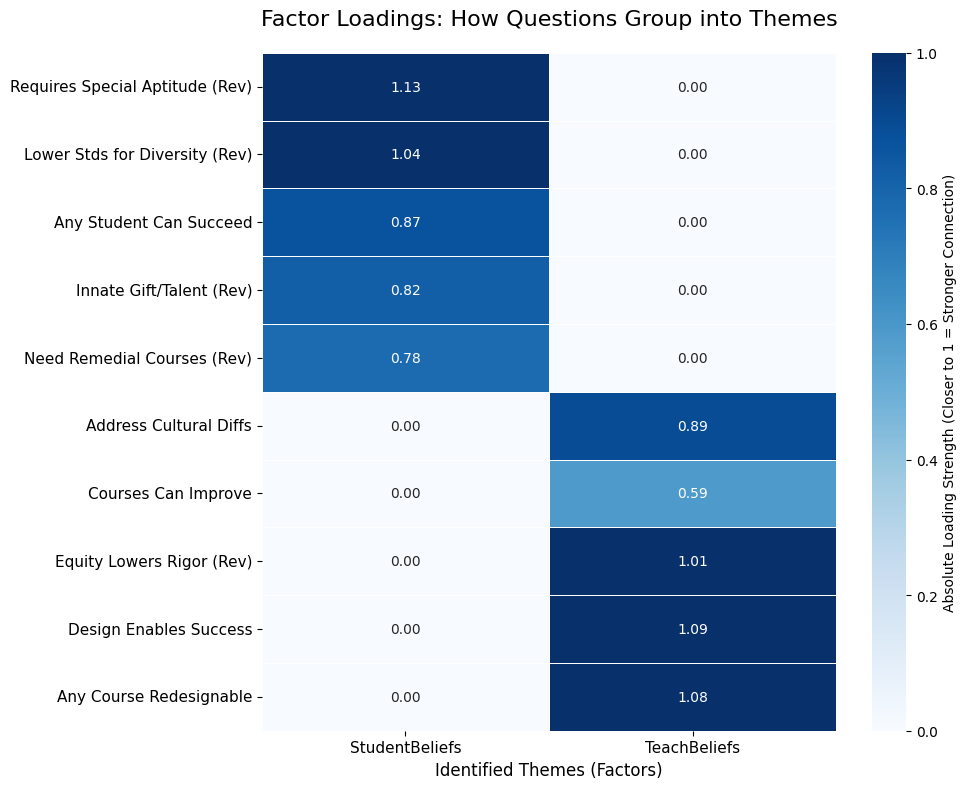

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Map the raw question codes to our readable short labels
labels_map = {
    'Q4_1_rev': 'Need Remedial Courses (Rev)', 
    'Q4_2_rev': 'Requires Special Aptitude (Rev)', 
    'Q4_3_rev': 'Innate Gift/Talent (Rev)',
    'Q4_4': 'Any Student Can Succeed', 
    'Q4_5_rev': 'Lower Stds for Diversity (Rev)',
    'Q5_1': 'Address Cultural Diffs', 
    'Q5_2': 'Courses Can Improve', 
    'Q5_3_rev': 'Equity Lowers Rigor (Rev)',
    'Q5_4': 'Design Enables Success', 
    'Q5_5': 'Any Course Redesignable'
}

# Apply the clean labels to the dataframe
loadings_clean = loadings_df.rename(index=labels_map)

# 2. Sort the items to make the groupings visually obvious
# This groups the strongest Factor 1 items at the top, and Factor 2 items at the bottom
if 'Factor 1' in loadings_clean.columns:  # If using EFA
    loadings_clean = loadings_clean.sort_values(by=['Factor 1'], ascending=False)
else: # If using CFA
    loadings_clean = loadings_clean.sort_values(by=[loadings_clean.columns[0]], ascending=False)

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))

# We use .abs() for the color mapping so that strong negative numbers still show up as dark/strong colors,
# but we pass the original data to 'annot' so you still see the real numbers.
sns.heatmap(loadings_clean.abs(), 
            annot=loadings_clean,      # Show the actual numbers inside the boxes
            cmap='Blues',              # Berkeley Blue color scale
            vmin=0, vmax=1,            # Scale from 0 to 1
            fmt=".2f",                 # Round to 2 decimal places
            linewidths=.5, 
            cbar_kws={'label': 'Absolute Loading Strength (Closer to 1 = Stronger Connection)'})

plt.title('Factor Loadings: How Questions Group into Themes', fontsize=16, pad=20)
plt.ylabel('')
plt.xlabel('Identified Themes (Factors)', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

plt.show()

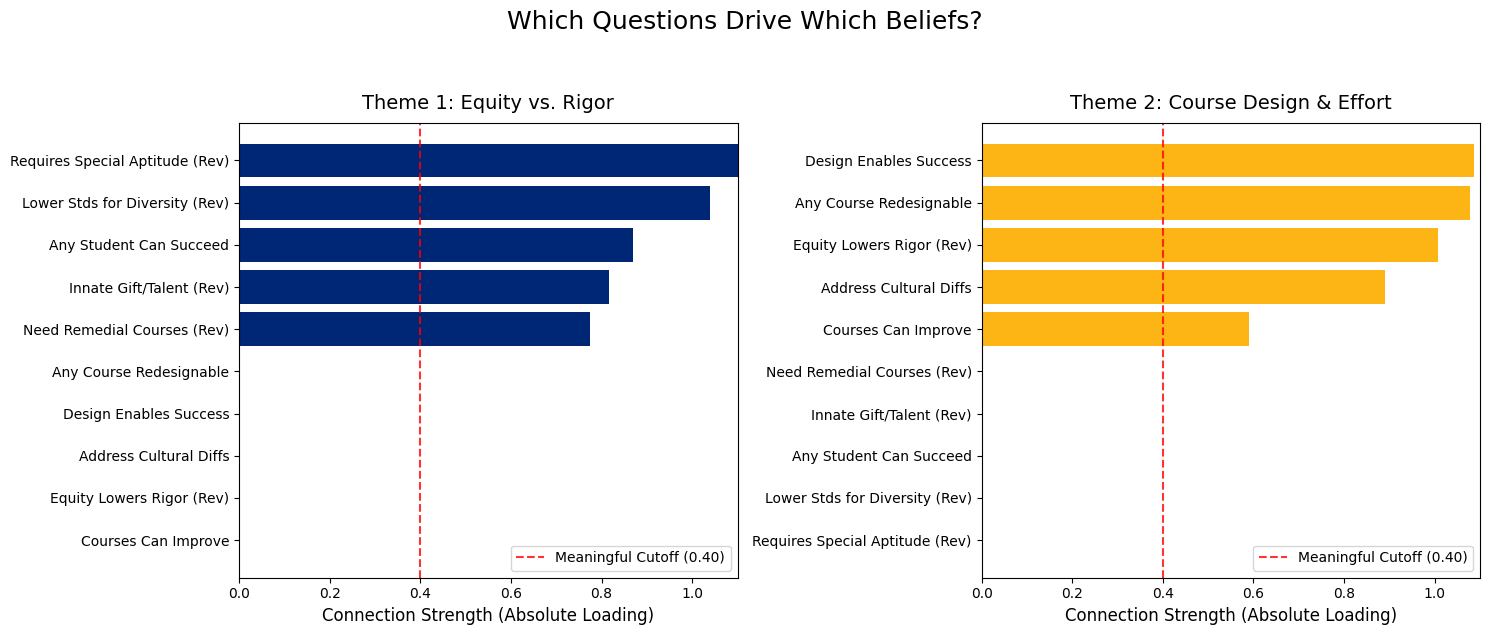

In [13]:
import matplotlib.pyplot as plt

# Grab the column names dynamically (whether they are 'Factor 1' or 'StudentBeliefs')
theme_1_name = loadings_clean.columns[0]
theme_2_name = loadings_clean.columns[1]

# Create a figure with 2 side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- PLOT 1: THEME 1 ---
# Sort the data by absolute strength for the first theme
theme_1_data = loadings_clean[theme_1_name].abs().sort_values(ascending=True)

# Create a horizontal bar chart in Berkeley Blue
axes[0].barh(theme_1_data.index, theme_1_data.values, color='#002676')
axes[0].set_title('Theme 1: Equity vs. Rigor', fontsize=14, pad=10)
axes[0].set_xlabel('Connection Strength (Absolute Loading)', fontsize=12)
axes[0].set_xlim(0, 1.1)

# Add a red threshold line at 0.40 to show what is "meaningful"
axes[0].axvline(0.40, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Meaningful Cutoff (0.40)')
axes[0].legend(loc='lower right')


# --- PLOT 2: THEME 2 ---
# Sort the data by absolute strength for the second theme
theme_2_data = loadings_clean[theme_2_name].abs().sort_values(ascending=True)

# Create a horizontal bar chart in Berkeley Gold
axes[1].barh(theme_2_data.index, theme_2_data.values, color='#FDB515')
axes[1].set_title('Theme 2: Course Design & Effort', fontsize=14, pad=10)
axes[1].set_xlabel('Connection Strength (Absolute Loading)', fontsize=12)
axes[1].set_xlim(0, 1.1)

# Add a red threshold line at 0.40
axes[1].axvline(0.40, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Meaningful Cutoff (0.40)')
axes[1].legend(loc='lower right')


# --- FORMATTING ---
plt.suptitle('Which Questions Drive Which Beliefs?', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [14]:
# Compare the 'preview' rows to the campus average
print("Average Scores for ALL Berkeley Instructors:")
print(df[['StudentBeliefs_Score', 'TeachBeliefs_Score']].mean())

Average Scores for ALL Berkeley Instructors:
StudentBeliefs_Score    3.080084
TeachBeliefs_Score      4.017083
dtype: float64


In [15]:
import semopy
import pandas as pd

# The model descriptions using semopy syntax (using our reverse-coded dataframe)
models = {
    "1. Baseline (All 10 Items)": """
        StudentBeliefs =~ Q4_1_rev + Q4_2_rev + Q4_3_rev + Q4_4 + Q4_5_rev
        TeachBeliefs =~ Q5_1 + Q5_2 + Q5_3_rev + Q5_4 + Q5_5
    """,
    
    "2. Step 1 (Drop Q4_3 & Q4_4)": """
        StudentBeliefs =~ Q4_1_rev + Q4_2_rev + Q4_5_rev
        TeachBeliefs =~ Q5_1 + Q5_2 + Q5_3_rev + Q5_4 + Q5_5
    """,
    
    "3. Step 2 (Drop Q5_2)": """
        StudentBeliefs =~ Q4_1_rev + Q4_2_rev + Q4_5_rev
        TeachBeliefs =~ Q5_1 + Q5_3_rev + Q5_4 + Q5_5
    """,
    
    "4. Step 3 (Drop Q4_1)": """
        StudentBeliefs =~ Q4_2_rev + Q4_5_rev
        TeachBeliefs =~ Q5_1 + Q5_3_rev + Q5_4 + Q5_5
    """
}

# Run the models and collect the fit statistics
fit_results = []

for name, desc in models.items():
    # Initialize and fit the model
    mod = semopy.Model(desc)
    res = mod.fit(df_model) # df_model from our previous step
    
    # Calculate fit statistics
    stats = semopy.calc_stats(mod)
    
    # Extract CFI, TLI, and RMSEA
    fit_results.append({
        "Model Version": name,
        "CFI": stats['CFI'].values[0],
        "TLI": stats['TLI'].values[0],
        "RMSEA": stats['RMSEA'].values[0]
    })

# Display the results in a clean table
fit_df = pd.DataFrame(fit_results)
print("=== CFA MODEL FIT: STEPWISE DELETION ===")
print(fit_df.to_string(index=False))

=== CFA MODEL FIT: STEPWISE DELETION ===
               Model Version      CFI      TLI    RMSEA
  1. Baseline (All 10 Items) 0.871746 0.830252 0.103651
2. Step 1 (Drop Q4_3 & Q4_4) 0.868293 0.805906 0.135837
       3. Step 2 (Drop Q5_2) 0.906067 0.848261 0.133573
       4. Step 3 (Drop Q4_1) 0.910369 0.831942 0.162572


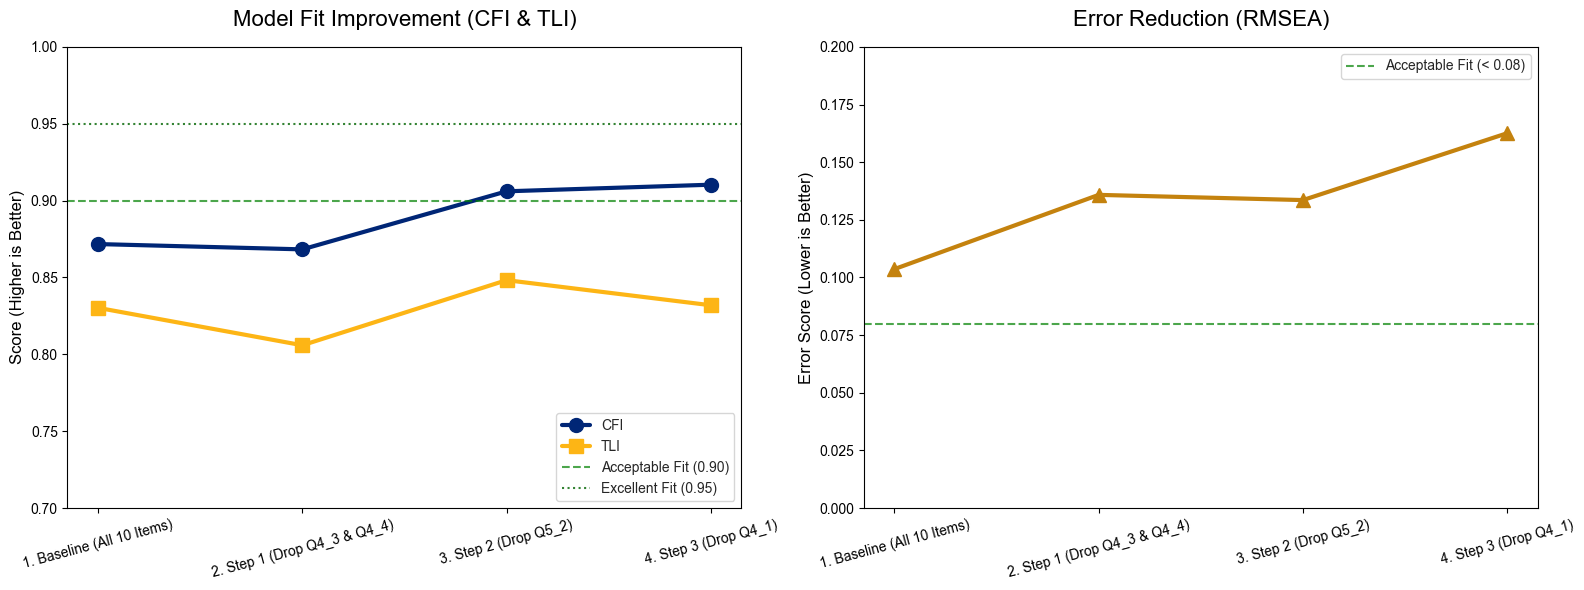

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")

# --- PLOT 1: CFI & TLI (Higher is Better) ---
axes[0].plot(fit_df['Model Version'], fit_df['CFI'], marker='o', linewidth=3, markersize=10, label='CFI', color='#002676') # Berkeley Blue
axes[0].plot(fit_df['Model Version'], fit_df['TLI'], marker='s', linewidth=3, markersize=10, label='TLI', color='#FDB515') # Berkeley Gold

# Add Threshold Lines
axes[0].axhline(y=0.90, color='green', linestyle='--', alpha=0.7, label='Acceptable Fit (0.90)')
axes[0].axhline(y=0.95, color='darkgreen', linestyle=':', alpha=0.8, label='Excellent Fit (0.95)')

axes[0].set_title('Model Fit Improvement (CFI & TLI)', fontsize=16, pad=15)
axes[0].set_ylabel('Score (Higher is Better)', fontsize=12)
axes[0].set_ylim(0.70, 1.0) # Scale appropriately
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(loc='lower right')


# --- PLOT 2: RMSEA (Lower is Better) ---
axes[1].plot(fit_df['Model Version'], fit_df['RMSEA'], marker='^', linewidth=3, markersize=10, color='#C4820E') # Dark Gold

# Add Threshold Line
axes[1].axhline(y=0.08, color='green', linestyle='--', alpha=0.7, label='Acceptable Fit (< 0.08)')

axes[1].set_title('Error Reduction (RMSEA)', fontsize=16, pad=15)
axes[1].set_ylabel('Error Score (Lower is Better)', fontsize=12)
axes[1].set_ylim(0.0, 0.20) # Scale appropriately
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(loc='upper right')

# --- Formatting ---
plt.tight_layout()
plt.show()

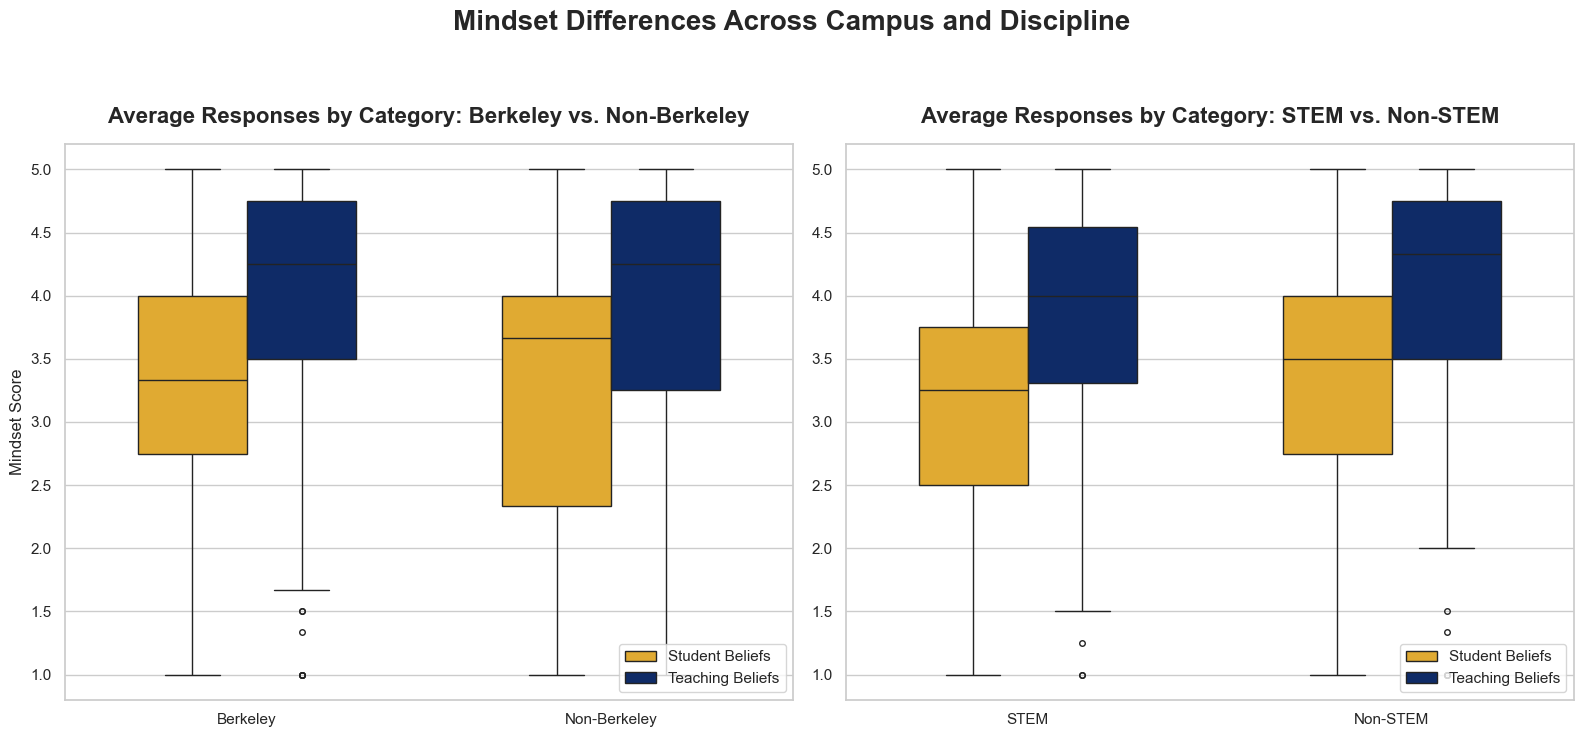

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD & CLEAN THE DATA
# ==========================================
# Load the data - Make sure the file name matches exactly
df_all = pd.read_csv('apr6_data.csv')

# Drop the first row (the Qualtrics question text)
df_data = df_all.iloc[1:].copy()

# Create Campus Group
df_data['Campus_Group'] = np.where(df_data['Q11'] == 'UC Berkeley', 'Berkeley', 'Non-Berkeley')

# Create Discipline Group (STEM vs Non-STEM)
stem_flag = df_data.apply(lambda row: row.astype(str).str.contains('Science, Technology, Engineering, and Math', na=False).any(), axis=1)
df_data['Discipline_Group'] = np.where(stem_flag, 'STEM', 'Non-STEM')

# ==========================================
# 2. CALCULATE MINDSET SCORES
# ==========================================
# Map text responses to numbers (1-5)
mapping = {
    'Strongly disagree': 1,
    'Somewhat disagree': 2,
    'Neither agree nor disagree': 3,
    'Somewhat agree': 4,
    'Strongly agree': 5
}

# We exclude Q4_3 and Q5_2 based on our CFA stepwise deletion findings
q4_cols = ['Q4_1', 'Q4_2', 'Q4_4', 'Q4_5'] 
q5_cols = ['Q5_1', 'Q5_3', 'Q5_4', 'Q5_5'] 

# Apply mapping to all relevant columns
for col in q4_cols + q5_cols:
    df_data[col] = df_data[col].map(mapping)

# Reverse code the fixed mindset items so 5 is always Growth/Equity
rev_cols = ['Q4_1', 'Q4_2', 'Q4_5', 'Q5_3']
for col in rev_cols:
    df_data[col] = 6 - df_data[col]

# Calculate the final averages for each person
df_data['Student Beliefs'] = df_data[q4_cols].mean(axis=1)
df_data['Teaching Beliefs'] = df_data[q5_cols].mean(axis=1)

# ==========================================
# 3. RESHAPE DATA FOR GROUPED PLOTTING
# ==========================================
# pd.melt "stacks" the scores so Seaborn can group them side-by-side
df_melted = pd.melt(
    df_data, 
    id_vars=['Campus_Group', 'Discipline_Group'], 
    value_vars=['Student Beliefs', 'Teaching Beliefs'],
    var_name='Belief_Type', 
    value_name='Score'
)

# Drop any missing scores so the plot is clean
df_melted = df_melted.dropna(subset=['Score'])

# ==========================================
# 4. PLOT THE RESULTS
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Berkeley colors for the grouped bars
my_palette = {"Student Beliefs": "#FDB515", "Teaching Beliefs": "#002676"} 

# PLOT 1: Campus Comparison
sns.boxplot(
    data=df_melted, 
    x='Campus_Group', 
    y='Score', 
    hue='Belief_Type',
    ax=axes[0],
    palette=my_palette,
    width=0.6,          # Adjusts box width
    fliersize=4         # Makes outlier dots look cleaner
)
axes[0].set_title('Average Responses by Category: Berkeley vs. Non-Berkeley', fontsize=16, weight='bold', pad=15)
axes[0].set_ylabel('Mindset Score', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylim(0.8, 5.2)
axes[0].legend(title='', loc='lower right')

# PLOT 2: Discipline Comparison
sns.boxplot(
    data=df_melted, 
    x='Discipline_Group', 
    y='Score', 
    hue='Belief_Type',
    ax=axes[1],
    palette=my_palette,
    width=0.6,
    fliersize=4
)
axes[1].set_title('Average Responses by Category: STEM vs. Non-STEM', fontsize=16, weight='bold', pad=15)
axes[1].set_ylabel('')
axes[1].set_xlabel('')
axes[1].set_ylim(0.8, 5.2)
axes[1].legend(title='', loc='lower right')

# Final Polish
plt.suptitle('Mindset Differences Across Campus and Discipline', fontsize=20, y=1.05, weight='bold')
plt.tight_layout()
plt.show()

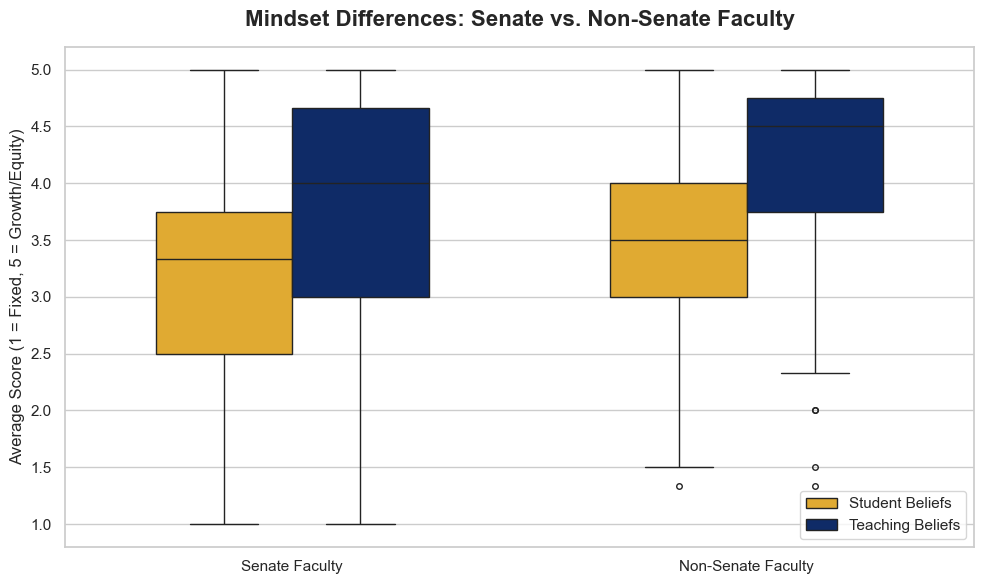

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. THE FIX: Recreate the missing Faculty_Status column
df_data['Faculty_Status'] = np.where(df_data['Q12'].astype(str).str.contains('Senate', na=False), 'Senate Faculty', 'Non-Senate Faculty')


# 2. Reshape the data specifically for Faculty Status
df_melted_faculty = pd.melt(
    df_data, 
    id_vars=['Faculty_Status'], 
    value_vars=['Student Beliefs', 'Teaching Beliefs'],
    var_name='Belief_Type', 
    value_name='Score'
)

# Drop missing scores
df_melted_faculty = df_melted_faculty.dropna(subset=['Score'])


# 3. Plot the Results
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

my_palette = {"Student Beliefs": "#FDB515", "Teaching Beliefs": "#002676"} 

sns.boxplot(
    data=df_melted_faculty, 
    x='Faculty_Status', 
    y='Score', 
    hue='Belief_Type',
    palette=my_palette,
    width=0.6,
    fliersize=4
)

# Formatting
plt.title('Mindset Differences: Senate vs. Non-Senate Faculty', fontsize=16, weight='bold', pad=15)
plt.ylabel('Average Score (1 = Fixed, 5 = Growth/Equity)', fontsize=12)
plt.xlabel('')
plt.ylim(0.8, 5.2) # Changed from 1 to 0.8
plt.legend(title='', loc='lower right')
plt.tight_layout()

# Save and show
plt.savefig('faculty_status_mindsets.png', dpi=300, bbox_inches='tight')
plt.show()

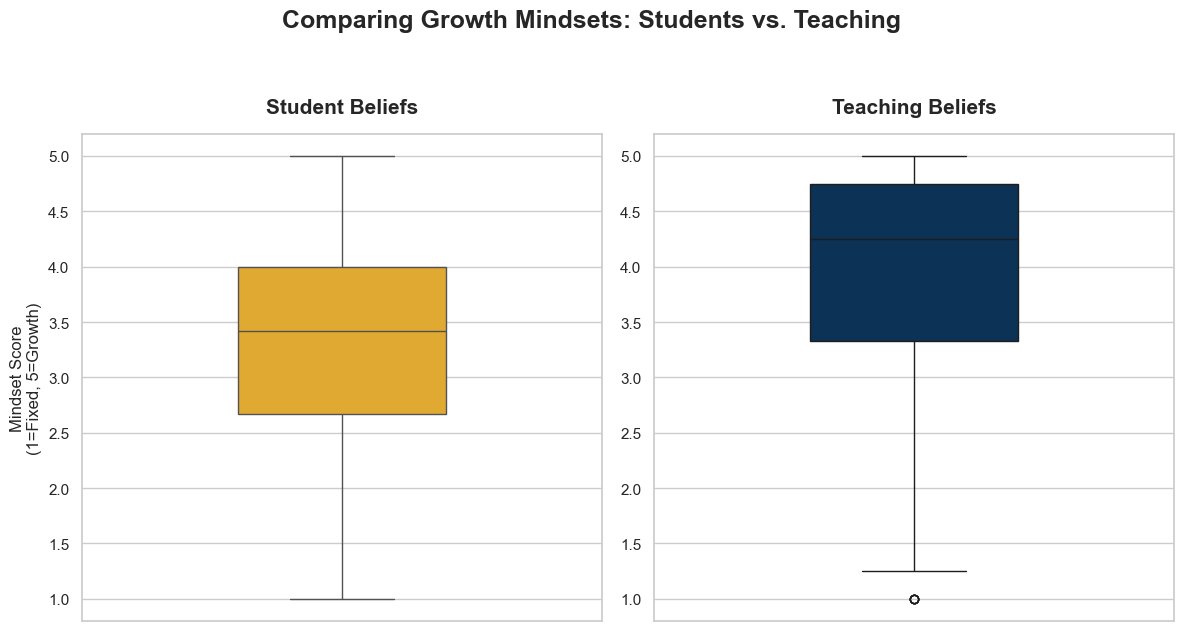

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD & PREPARE DATA
# ==========================================
# Re-loading to ensure a clean slate
df_all = pd.read_csv('apr6_data.csv')
df_data = df_all.iloc[1:].copy()

# Mapping and Scoring (Using our cleaned CFA items)
mapping = {
    'Strongly disagree': 1, 
    'Somewhat disagree': 2, 
    'Neither agree nor disagree': 3, 
    'Somewhat agree': 4, 
    'Strongly agree': 5
}

# Questions to include after CFA cleanup
q4_cols = ['Q4_1', 'Q4_2', 'Q4_4', 'Q4_5'] 
q5_cols = ['Q5_1', 'Q5_3', 'Q5_4', 'Q5_5'] 

# Convert text to numbers
for col in q4_cols + q5_cols:
    df_data[col] = pd.to_numeric(df_data[col].map(mapping), errors='coerce')

# Reverse coding (so 5 always means Growth/Equity)
for col in ['Q4_1', 'Q4_2', 'Q4_5', 'Q5_3']:
    df_data[col] = 6 - df_data[col]

# Calculate averages
df_data['Student Beliefs'] = df_data[q4_cols].mean(axis=1)
df_data['Teaching Beliefs'] = df_data[q5_cols].mean(axis=1)

# ==========================================
# 2. GENERATE SIDE-BY-SIDE FIGURE
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left Plot: Student Beliefs (The "Disparity" Story)
sns.boxplot(y=df_data['Student Beliefs'], ax=axes[0], color='#FDB515', width=0.4) # Berkeley Gold
axes[0].set_title('Student Beliefs', fontsize=15, weight='bold', pad=15)
axes[0].set_ylabel('Mindset Score\n(1=Fixed, 5=Growth)', fontsize=12)
axes[0].set_ylim(0.8, 5.2) # Fixed the whisker clipping

# Right Plot: Teaching Beliefs (The "Consensus" Story)
sns.boxplot(y=df_data['Teaching Beliefs'], ax=axes[1], color='#003262', width=0.4) # Berkeley Blue
axes[1].set_title('Teaching Beliefs', fontsize=15, weight='bold', pad=15)
axes[1].set_ylabel('') # Keep it clean
axes[1].set_ylim(0.8, 5.2)

# Final formatting
plt.suptitle('Comparing Growth Mindsets: Students vs. Teaching', fontsize=18, y=1.05, weight='bold')
plt.tight_layout()

# Save for your poster
plt.savefig('mindset_comparison_side_by_side.png', dpi=300, bbox_inches='tight')
plt.show()

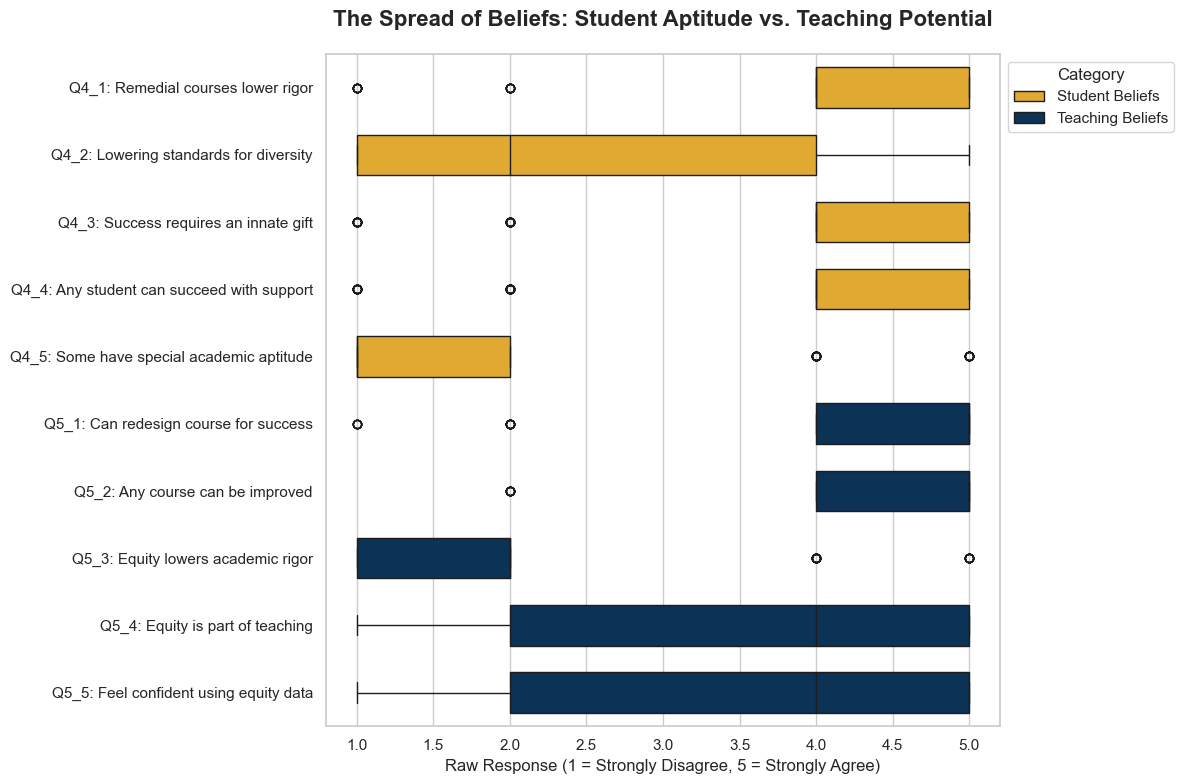

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load and Map Data
df_all = pd.read_csv('apr6_data.csv')
df_data = df_all.iloc[1:].copy()

mapping = {'Strongly disagree': 1, 'Somewhat disagree': 2, 'Neither agree nor disagree': 3, 'Somewhat agree': 4, 'Strongly agree': 5}
q4_cols = ['Q4_1', 'Q4_2', 'Q4_3', 'Q4_4', 'Q4_5'] # Including Q4_3 to show its spread!
q5_cols = ['Q5_1', 'Q5_2', 'Q5_3', 'Q5_4', 'Q5_5'] 

for col in q4_cols + q5_cols:
    df_data[col] = pd.to_numeric(df_data[col].map(mapping), errors='coerce')

# 2. Reshape for a "Spread" Comparison
# We will NOT reverse code here, so we can see the raw 1-5 responses
df_items = pd.melt(df_data, value_vars=q4_cols + q5_cols, var_name='Question', value_name='Score').dropna()

# Labeling the questions for the y-axis
labels = {
    'Q4_1': 'Q4_1: Remedial courses lower rigor',
    'Q4_2': 'Q4_2: Lowering standards for diversity',
    'Q4_3': 'Q4_3: Success requires an innate gift',
    'Q4_4': 'Q4_4: Any student can succeed with support',
    'Q4_5': 'Q4_5: Some have special academic aptitude',
    'Q5_1': 'Q5_1: Can redesign course for success',
    'Q5_2': 'Q5_2: Any course can be improved',
    'Q5_3': 'Q5_3: Equity lowers academic rigor',
    'Q5_4': 'Q5_4: Equity is part of teaching',
    'Q5_5': 'Q5_5: Feel confident using equity data'
}
df_items['Question_Text'] = df_items['Question'].map(labels)
df_items['Category'] = np.where(df_items['Question'].str.startswith('Q4'), 'Student Beliefs', 'Teaching Beliefs')

# 3. Create the Visualization
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Define palette
palette = {'Student Beliefs': '#FDB515', 'Teaching Beliefs': '#003262'} # Gold vs Blue

sns.boxplot(
    data=df_items, 
    x='Score', 
    y='Question_Text', 
    hue='Category', 
    palette=palette,
    width=0.6,
    dodge=False # Keep items in a single vertical line
)

plt.title('The Spread of Beliefs: Student Aptitude vs. Teaching Potential', fontsize=16, weight='bold', pad=20)
plt.xlabel('Raw Response (1 = Strongly Disagree, 5 = Strongly Agree)', fontsize=12)
plt.ylabel('')
plt.xlim(0.8, 5.2)
plt.legend(title='Category', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.savefig('item_level_spread.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\lynnc\AppData\Local\Temp\ipykernel_34672\2641611059.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_avg, x='Mindset Type', y='Average Score', palette=palette, width=0.5)


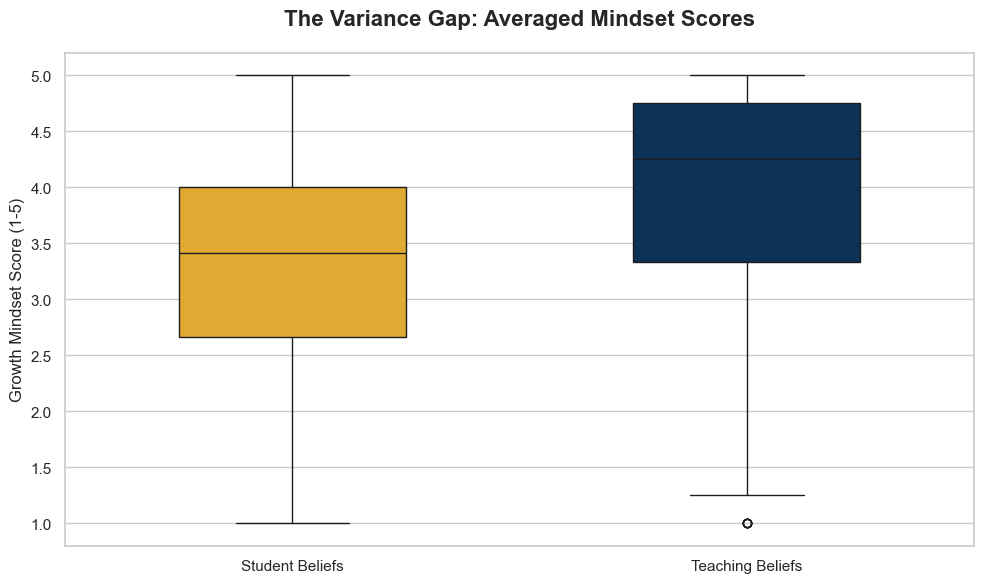

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load and Setup
df_all = pd.read_csv('apr6_data.csv')
df_data = df_all.iloc[1:].copy()

mapping = {'Strongly disagree': 1, 'Somewhat disagree': 2, 'Neither agree nor disagree': 3, 'Somewhat agree': 4, 'Strongly agree': 5}
q4_cols = ['Q4_1', 'Q4_2', 'Q4_4', 'Q4_5'] 
q5_cols = ['Q5_1', 'Q5_3', 'Q5_4', 'Q5_5'] 

for col in q4_cols + q5_cols:
    df_data[col] = pd.to_numeric(df_data[col].map(mapping), errors='coerce')

# Reverse code so 5 always = Growth/Equity
for col in ['Q4_1', 'Q4_2', 'Q4_5', 'Q5_3']:
    df_data[col] = 6 - df_data[col]

# Calculate the averages for each person
df_data['Student Beliefs'] = df_data[q4_cols].mean(axis=1)
df_data['Teaching Beliefs'] = df_data[q5_cols].mean(axis=1)

# 2. Reshape for the boxplot
df_avg = pd.melt(df_data, value_vars=['Student Beliefs', 'Teaching Beliefs'], 
                 var_name='Mindset Type', value_name='Average Score').dropna()

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Student = Gold, Teaching = Blue
palette = {'Student Beliefs': '#FDB515', 'Teaching Beliefs': '#003262'}

sns.boxplot(data=df_avg, x='Mindset Type', y='Average Score', palette=palette, width=0.5)

plt.title('The Variance Gap: Averaged Mindset Scores', fontsize=16, weight='bold', pad=20)
plt.ylabel('Growth Mindset Score (1-5)', fontsize=12)
plt.xlabel('')
plt.ylim(0.8, 5.2)

plt.tight_layout()
plt.savefig('averaged_mindset_spread.png', dpi=300)
plt.show()

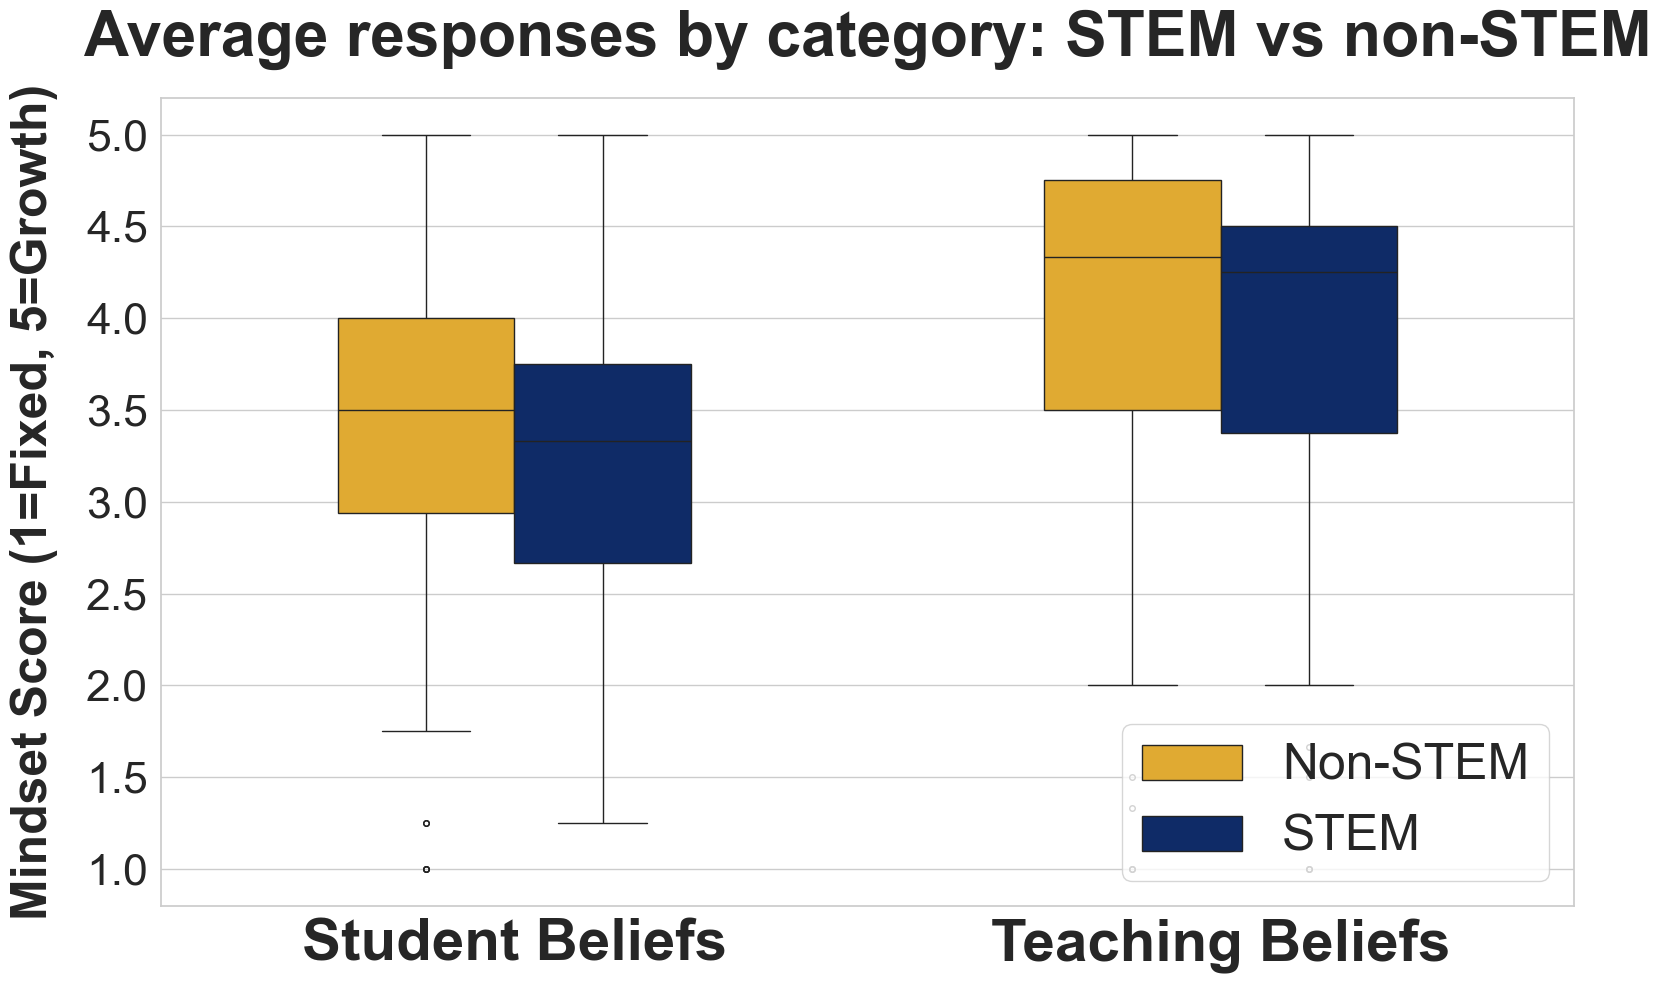

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD & PREPARE DATA
# ==========================================
# Load fresh to avoid any missing variable errors
df_all = df.copy()
df_data = df_all.iloc[1:].copy()

# Create Discipline Group (STEM vs Non-STEM)
stem_flag = df_data.apply(lambda row: row.astype(str).str.contains('Science, Technology, Engineering, and Math', na=False).any(), axis=1)
df_data['Discipline_Group'] = np.where(stem_flag, 'STEM', 'Non-STEM')

# Mapping and Scoring (Using cleaned CFA items)
mapping = {
    'Strongly disagree': 1, 'Somewhat disagree': 2, 
    'Neither agree nor disagree': 3, 'Somewhat agree': 4, 'Strongly agree': 5
}
q4_cols = ['Q4_1', 'Q4_2', 'Q4_4', 'Q4_5'] 
q5_cols = ['Q5_1', 'Q5_3', 'Q5_4', 'Q5_5'] 

for col in q4_cols + q5_cols:
    df_data[col] = pd.to_numeric(df_data[col].map(mapping), errors='coerce')

# Reverse coding (so 5 always means Growth/Equity)
for col in ['Q4_1', 'Q4_2', 'Q4_5', 'Q5_3']:
    df_data[col] = 6 - df_data[col]

# Calculate averages
df_data['Student Beliefs'] = df_data[q4_cols].mean(axis=1)
df_data['Teaching Beliefs'] = df_data[q5_cols].mean(axis=1)

# ==========================================
# 2. RESHAPE DATA FOR GROUPED BOXPLOT
# ==========================================
# This stacks the data so Seaborn can group by Belief Type AND Discipline
df_melted = pd.melt(
    df_data, 
    id_vars=['Discipline_Group'], 
    value_vars=['Student Beliefs', 'Teaching Beliefs'],
    var_name='Belief_Type', 
    value_name='Score'
).dropna(subset=['Score'])

# ==========================================
# 3. GENERATE THE CHART
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# Yellow for STEM, Blue for Non-STEM
discipline_palette = {'STEM': '#002676', 'Non-STEM': '#FDB515'} 

# Create the grouped boxplot
sns.boxplot(
    data=df_melted, 
    x='Belief_Type', 
    y='Score', 
    hue='Discipline_Group',
    palette=discipline_palette,
    width=0.5,
    fliersize=4
)
# --- MASSIVE FONT SIZING ---
plt.title('Average responses by category: STEM vs non-STEM', fontsize=45, weight='bold', pad=30)
plt.ylabel('Mindset Score (1=Fixed, 5=Growth)', fontsize=36, weight='bold', labelpad=20)
plt.xlabel('') 
plt.ylim(0.8, 5.2) 

# Increase axis tick mark text
plt.xticks(fontsize=42, weight='bold') # Make "Student Beliefs" pop
plt.yticks(fontsize=32)

# Scale up the legend
plt.legend(title='', fontsize=36, loc='lower right')

plt.tight_layout()

plt.show()

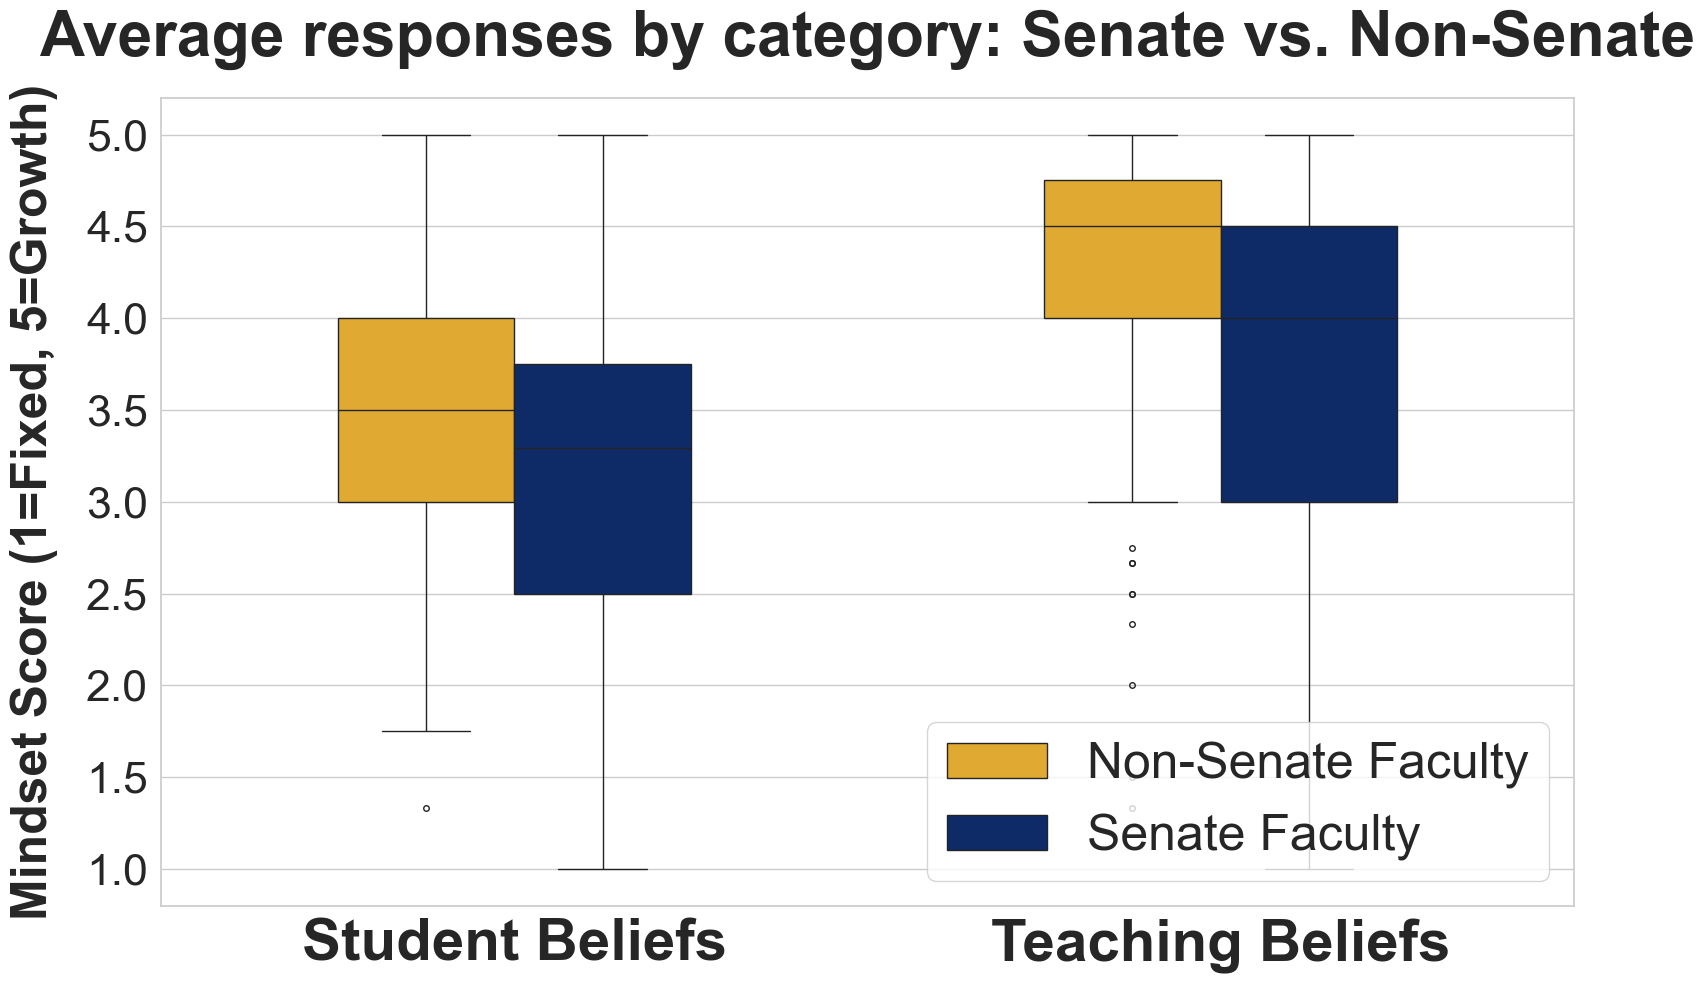

In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD & PREPARE DATA
# ==========================================
# Load fresh to ensure a clean slate
df_all = df.copy()
df_data = df_all.iloc[1:].copy()

# Create Faculty Status Group
df_data['Faculty_Status'] = np.where(
    df_data['Q12'].astype(str).str.contains('Senate', na=False), 
    'Senate Faculty', 'Non-Senate Faculty'
)

# Mapping and Scoring (Using cleaned CFA items)
mapping = {
    'Strongly disagree': 1, 'Somewhat disagree': 2, 
    'Neither agree nor disagree': 3, 'Somewhat agree': 4, 'Strongly agree': 5
}
q4_cols = ['Q4_1', 'Q4_2', 'Q4_4', 'Q4_5'] 
q5_cols = ['Q5_1', 'Q5_3', 'Q5_4', 'Q5_5'] 

for col in q4_cols + q5_cols:
    df_data[col] = pd.to_numeric(df_data[col].map(mapping), errors='coerce')

# Reverse coding (so 5 always means Growth/Equity)
for col in ['Q4_1', 'Q4_2', 'Q4_5', 'Q5_3']:
    df_data[col] = 6 - df_data[col]

# Calculate averages
df_data['Student Beliefs'] = df_data[q4_cols].mean(axis=1)
df_data['Teaching Beliefs'] = df_data[q5_cols].mean(axis=1)

# ==========================================
# 2. RESHAPE DATA FOR GROUPED BOXPLOT
# ==========================================
# This stacks the data so Seaborn can group by Belief Type AND Faculty Status
df_melted_faculty = pd.melt(
    df_data, 
    id_vars=['Faculty_Status'], 
    value_vars=['Student Beliefs', 'Teaching Beliefs'],
    var_name='Belief_Type', 
    value_name='Score'
).dropna(subset=['Score'])

# ==========================================
# 3. GENERATE THE CHART
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

# Define palette (Berkeley Blue & Gold)
faculty_palette = {'Senate Faculty': '#002676', 'Non-Senate Faculty': '#FDB515'} 

# Create the grouped boxplot
sns.boxplot(
    data=df_melted_faculty, 
    x='Belief_Type', 
    y='Score', 
    hue='Faculty_Status',
    palette=faculty_palette,
    width=0.5,
    fliersize=4
)
# --- MASSIVE FONT SIZING ---
plt.title('Average responses by category: Senate vs. Non-Senate', fontsize=45, weight='bold', pad=30)
plt.ylabel('Mindset Score (1=Fixed, 5=Growth)', fontsize=36, weight='bold', labelpad=20)
plt.xlabel('') 
plt.ylim(0.8, 5.2) 

# Increase axis tick mark text
plt.xticks(fontsize=42, weight='bold') # Make "Student Beliefs" pop
plt.yticks(fontsize=32)

# Scale up the legend
plt.legend(title='', fontsize=36, loc='lower right')

plt.tight_layout()

plt.show()

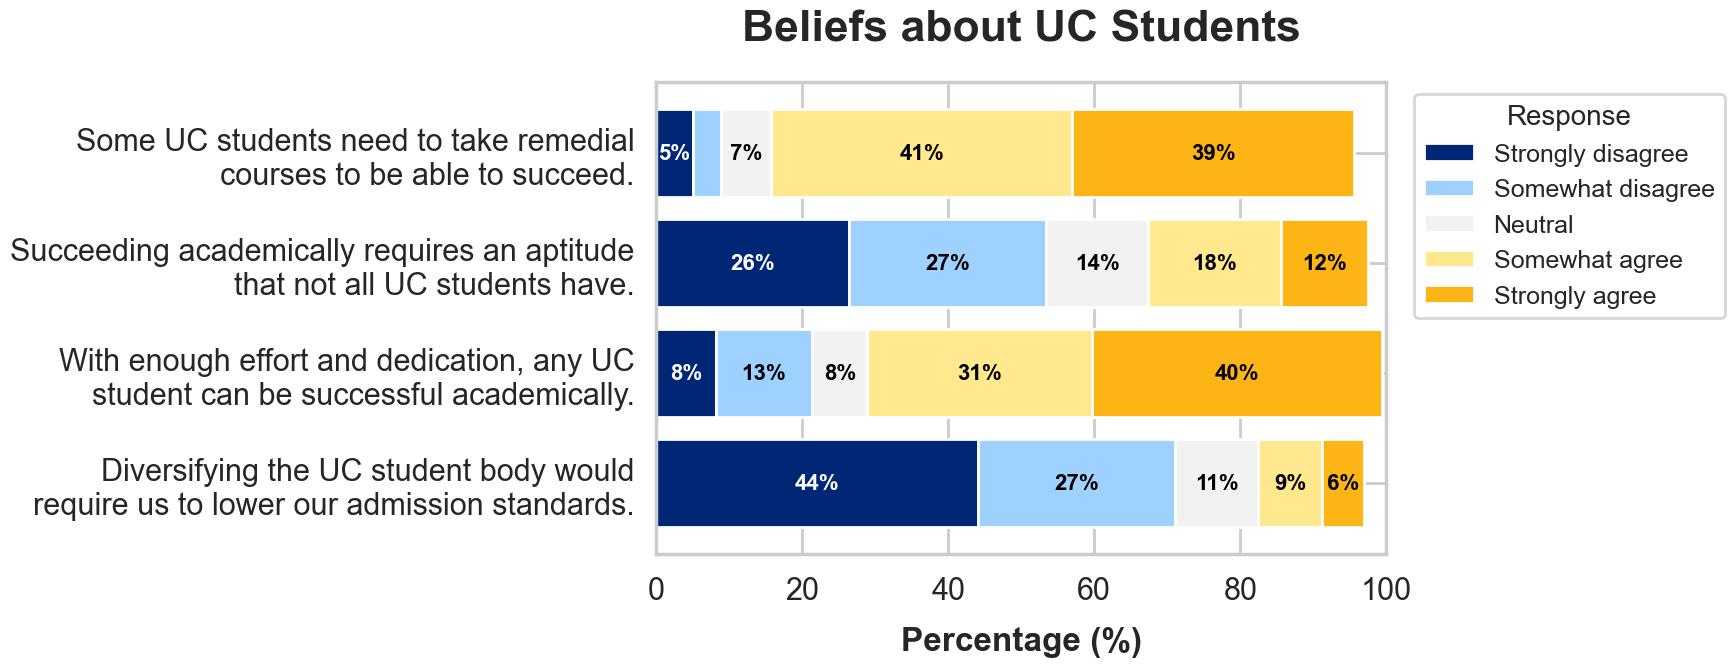

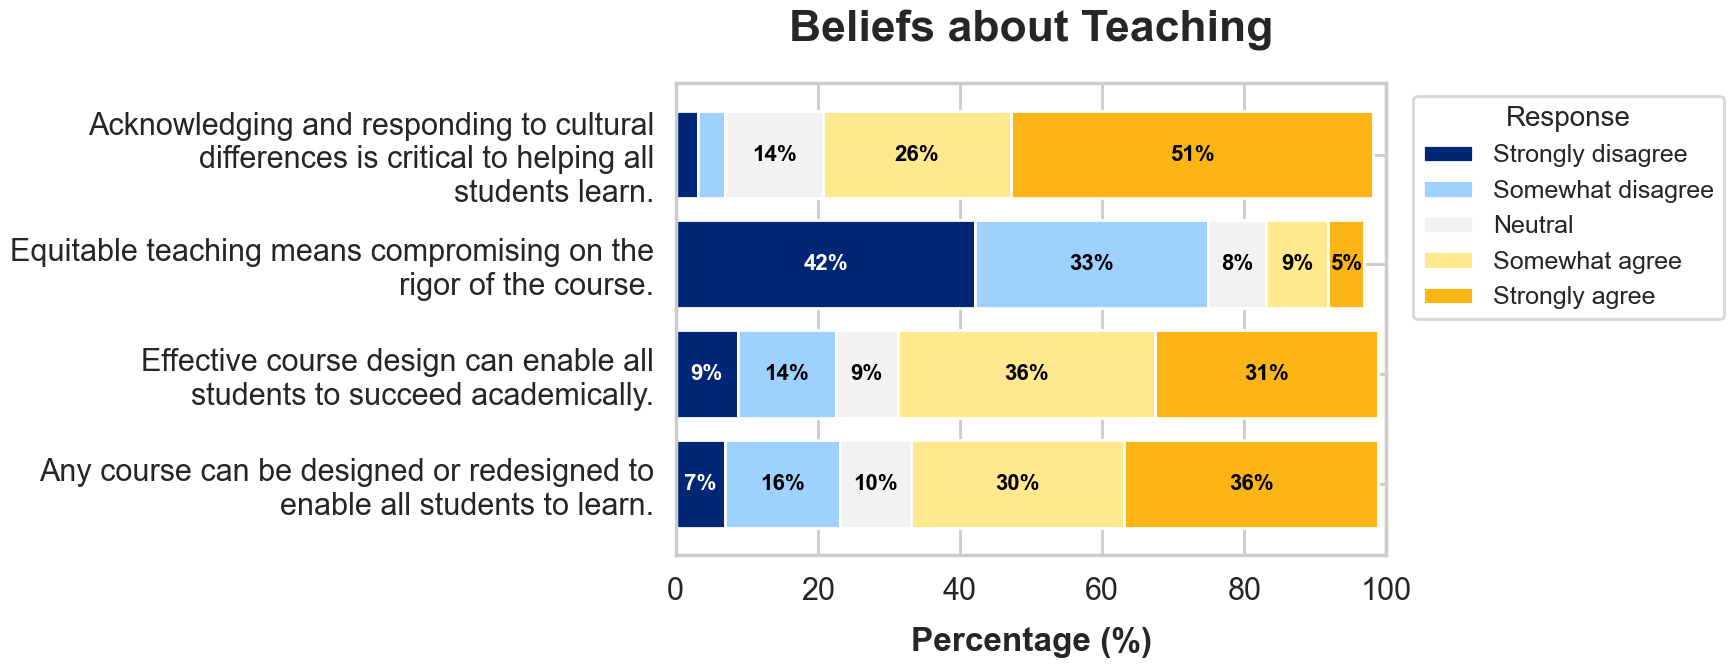

NameError: name 'q6_cols' is not defined

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# Your existing setup variables
agree_order = ['Strongly disagree', 'Somewhat disagree', 'Neutral', 'Somewhat agree', 'Strongly agree']
conf_order = ['Not confident at all', 'Slightly confident', 'Moderately confident', 'Very confident']

custom_colors_5 = ['#002676', '#9FD1FF', '#F2F2F2', '#FFE88D', '#FDB515']
text_colors_5 = ['white', 'black', 'black', 'black', 'black']

custom_colors_4 = ['#002676', '#9FD1FF', '#FFE88D', '#FDB515']
text_colors_4 = ['white', 'black', 'black', 'black']

# Modified Function for Poster Printing
def plot_likert_block_poster(data, cols, order, title, q_map, color_palette, text_colors, filename):
    results = {}
    for col in cols:
        full_text = q_map.get(col, col)
        label = full_text.split('-')[-1].strip() if '-' in full_text else full_text
        # Slightly wider wrap (45) since our poster figure is wider
        label = textwrap.fill(label, width=45) 
        vc = data[col].value_counts(normalize=True).reindex(order, fill_value=0) * 100
        results[label] = vc
        
    plot_df = pd.DataFrame(results).T
    
    # 1. MASSIVELY INCREASE FIGURE SIZE (Width=18, Height scales with questions)
    fig, ax = plt.subplots(figsize=(18, len(cols) * 1.8))
    
    # Made the bars slightly thicker (width=0.8) for better visibility
    plot_df.plot(kind='barh', stacked=True, ax=ax, color=color_palette, edgecolor='white', width=0.8)
    
    # 2. INCREASE TITLE AND X-AXIS FONT SIZES
    ax.set_title(title, fontsize=32, pad=30, weight='bold')
    ax.set_xlabel('Percentage (%)', fontsize=24, weight='bold', labelpad=15)
    ax.set_xlim(0, 100)
    
    # 3. INCREASE Y-AXIS (QUESTION TEXT) AND TICK MARK FONTS
    ax.tick_params(axis='x', labelsize=22)
    ax.tick_params(axis='y', labelsize=22) # Ensures questions are readable from a distance
    
    # 4. SCALE UP THE LEGEND
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Response", 
              fontsize=18, title_fontsize=20)
    ax.invert_yaxis()
    
    # 5. ENLARGE PERCENTAGE TEXT INSIDE THE BARS
    for i, c in enumerate(ax.containers):
        t_color = text_colors[i] if i < len(text_colors) else 'black'
        labels = [f'{v.get_width():.0f}%' if v.get_width() > 4 else '' for v in c]
        # Font size 16 for numbers inside the bar
        ax.bar_label(c, labels=labels, label_type='center', color=t_color, fontsize=16, weight='bold')
        
    plt.tight_layout()
    
    # 6. EXPORT AT 300 DPI FOR HIGH-RES PRINTING
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# df = pd.read_csv('apr6_data.csv')
# Run the functions (note the added filename string parameter at the end!)
plot_likert_block_poster(df, q4_cols, agree_order, "Beliefs about UC Students", question_map, custom_colors_5, text_colors_5, 'Q4_Poster.png')
plot_likert_block_poster(df, q5_cols, agree_order, "Beliefs about Teaching", question_map, custom_colors_5, text_colors_5, 'Q5_Poster.png')
plot_likert_block_poster(df, q6_cols, conf_order, "Confidence in Teaching Practices", question_map, custom_colors_4, text_colors_4, 'Q6_Poster.png')

In [ ]:
df_all = pd.read_csv('apr6_data.csv')
df_all.head()

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Q15_4,Q15_13,Q15_12,Q15_5,Q15_6,Q15_7,Q15_8,Q15_9,Q15_10,Q15_11
0,Start Date,End Date,Response Type,IP Address,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,Recipient Last Name,...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...,Please select all that apply. I identify as… -...
1,"{""ImportId"":""startDate"",""timeZone"":""America/Lo...","{""ImportId"":""endDate"",""timeZone"":""America/Los_...","{""ImportId"":""status""}","{""ImportId"":""ipAddress""}","{""ImportId"":""progress""}","{""ImportId"":""duration""}","{""ImportId"":""finished""}","{""ImportId"":""recordedDate"",""timeZone"":""America...","{""ImportId"":""_recordId""}","{""ImportId"":""recipientLastName""}",...,"{""ImportId"":""QID17"",""choiceId"":""4""}","{""ImportId"":""QID17"",""choiceId"":""13""}","{""ImportId"":""QID17"",""choiceId"":""12""}","{""ImportId"":""QID17"",""choiceId"":""5""}","{""ImportId"":""QID17"",""choiceId"":""6""}","{""ImportId"":""QID17"",""choiceId"":""7""}","{""ImportId"":""QID17"",""choiceId"":""8""}","{""ImportId"":""QID17"",""choiceId"":""9""}","{""ImportId"":""QID17"",""choiceId"":""10""}","{""ImportId"":""QID17"",""choiceId"":""11""}"
2,2025-09-12 08:42:09,2025-09-12 08:42:20,IP Address,76.102.247.118,100,11,True,2025-09-12 08:42:20,R_6eRAonwN0LYh66d,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-09-12 08:42:29,2025-09-12 08:43:51,IP Address,76.102.247.118,100,81,True,2025-09-12 08:43:51,R_7gSf9Ckv9RI55CU,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-09-13 22:14:17,2025-09-13 22:14:22,Survey Preview,NaN,100,4,True,2025-09-13 22:14:22,R_5iI6HIt9Hqrl5y9,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


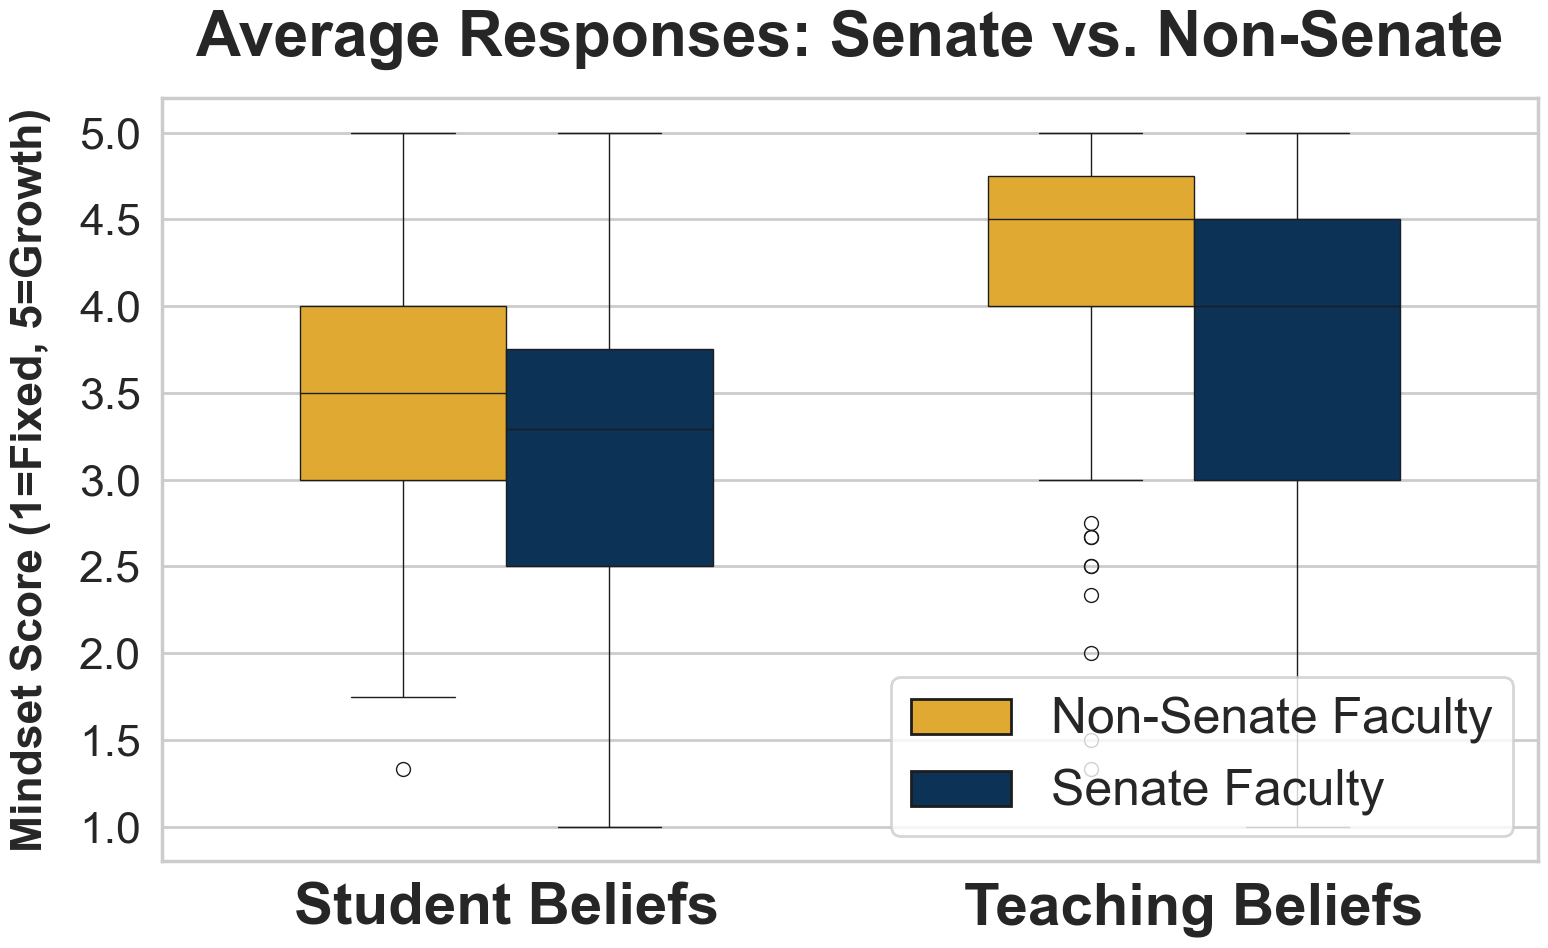

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD & PREPARE DATA
# ==========================================
df_all = df.copy()
df_all = df_all[df_all['Q11'] == 'UC Berkeley']
df_data = df_all.iloc[1:].copy()

# Create Faculty Status Group (Swap for STEM code if needed!)
df_data['Faculty_Status'] = np.where(
    df_data['Q12'].astype(str).str.contains('Senate', na=False), 
    'Senate Faculty', 'Non-Senate Faculty'
)

# Mapping and Scoring
mapping = {
    'Strongly disagree': 1, 'Somewhat disagree': 2, 
    'Neither agree nor disagree': 3, 'Somewhat agree': 4, 'Strongly agree': 5
}
q4_cols = ['Q4_1', 'Q4_2', 'Q4_4', 'Q4_5'] 
q5_cols = ['Q5_1', 'Q5_3', 'Q5_4', 'Q5_5'] 

for col in q4_cols + q5_cols:
    df_data[col] = pd.to_numeric(df_data[col].map(mapping), errors='coerce')

for col in ['Q4_1', 'Q4_2', 'Q4_5', 'Q5_3']:
    df_data[col] = 6 - df_data[col]

df_data['Student Beliefs'] = df_data[q4_cols].mean(axis=1)
df_data['Teaching Beliefs'] = df_data[q5_cols].mean(axis=1)

df_melted_faculty = pd.melt(
    df_data, 
    id_vars=['Faculty_Status'], 
    value_vars=['Student Beliefs', 'Teaching Beliefs'],
    var_name='Belief_Type', 
    value_name='Score'
).dropna(subset=['Score'])


# ==========================================
# 2. GENERATE POSTER-SIZED BOXPLOT
# ==========================================
# Instantly scale up the base UI
sns.set_theme(style="whitegrid", context="poster")

# Make the figure dimensions larger and wider
plt.figure(figsize=(16, 10))

faculty_palette = {'Senate Faculty': '#003262', 'Non-Senate Faculty': '#FDB515'} 

sns.boxplot(
    data=df_melted_faculty, 
    x='Belief_Type', 
    y='Score', 
    hue='Faculty_Status',
    palette=faculty_palette,
    width=0.6,
    fliersize=10 # Makes the outlier dots massive so they are visible from 5 feet away
)

# --- MASSIVE FONT SIZING ---
plt.title('Average Responses: Senate vs. Non-Senate', fontsize=45, weight='bold', pad=30)
plt.ylabel('Mindset Score (1=Fixed, 5=Growth)', fontsize=32, weight='bold', labelpad=20)
plt.xlabel('') 
plt.ylim(0.8, 5.2) 

# Increase axis tick mark text
plt.xticks(fontsize=42, weight='bold') # Make "Student Beliefs" pop
plt.yticks(fontsize=32)

# Scale up the legend
plt.legend(title='', fontsize=36, loc='lower right')

plt.tight_layout()

# Save at 300 DPI
plt.savefig('poster_ready_boxplot_senate.png', dpi=300, bbox_inches='tight')
plt.show()